<center>
<small>
Nova Information Management School<br>
Bachelor in Data Science, 2025-26<br>
Data Preprocessing and Visualization<br><br>
Project developed by Group 7<br>
Carolina Arez 20241739 · Henrique Madureira 20241756 · Miguel Melo 20241757 · Noa Penas 20241682
</small>
</center>

<hr style="border: 0.5px solid #0EE071;">

# <font> <strong>City Hospital – Data Preprocessing & Exploratory Analysis </strong> </font> <a class="anchor" id="P0"></a>

<hr style="border: 0.5px solid #0EE071;">

## <font color='#0EE071'>Table of Contents</font> <a class="anchor" id='toc'></a>

- [1. Part A – Data Understanding & Cleaning](#1)
  - [1.1 Importing the Data](#1_1)
  - [1.2 Initial understanding of the data set](#1_2)
  - [1.3 Handling duplicate rows and inconsistent data types](#1_3)
  - [1.4 Searching and fixing inconsistencies](#1_4)
  - [1.5 Filtering to find non logical occurences](#1_5)
  - [1.6 Handling outliers](#1_6)
  - [1.7 Handling missing values](#1_7)
- [2.  Part B- Feature Engineering & ABT Construction.](#2)
- [3. Part C – Exploratory Visualization & Insights](#3)

<br>

### <font color='#0EE071'>1. Part A – Data Understanding & Cleaning </font> <a class="anchor" id="1"></a>
  [Back to TOC](#toc)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

<br>

### <font> <strong> 1.1. Importing the Data </strong></font> <a class="anchor" id='1_1'></a>

In [3]:
data = pd.read_excel('Data/Project Data.xlsx')
df = data.copy()

<br>

### <font> <strong> 1.2. Initial understanding of the data set </strong></font> <a class="anchor" id='1_2'></a> 

In [5]:
df.head()

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
0,1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-02-22,Endocrinology,110,2,38839.0,293.014042,0.0
1,1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-01-21,Emergency,76,4,52219.0,287.208982,0.0
2,1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-06-13,Neurology,17,5,41491.0,241.254507,0.0
3,1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-24,Emergency,15,3,34944.0,221.177483,0.0
4,1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-19,Neurology,99,1,39248.0,219.743794,0.0


<br>

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10008 entries, 0 to 10007
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Patient ID                 10008 non-null  int64         
 1   Age                        9952 non-null   float64       
 2   Gender                     10008 non-null  object        
 3   City of Residence          10008 non-null  object        
 4   Profession                 10008 non-null  object        
 5   Insurance Provider         8098 non-null   object        
 6   Family History             8015 non-null   object        
 7   Education Level            9979 non-null   object        
 8   Marital Status             10008 non-null  object        
 9   Visit Date                 10008 non-null  datetime64[ns]
 10  Department                 10008 non-null  object        
 11  Consultation Duration      10008 non-null  int64         
 12  Sati

<br>

In [7]:
df.describe(include='all')

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
count,10008.000000,9952.000000,10008,10008,10008,8098,8015,9979,10008,10008,10008,10008.000000,10008.000000,9.854000e+03,10008.000000,9958.000000
unique,NaN,NaN,3,8,10,4,4,8,4,NaN,13,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Other,Birmingham,Retired,Provider D,Heart Disease,Undergraduate,Divorced,NaN,Psychiatry,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,3417,1473,3601,2165,2235,4160,2893,NaN,1361,NaN,NaN,NaN,NaN,NaN
mean,1251.580735,50.635651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-31 14:53:14.244604160,NaN,67.807654,3.202338,4.340276e+04,187.263022,115.429366
min,1000.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:00:00,NaN,15.000000,1.000000,0.000000e+00,50.036762,0.000000
25%,1127.000000,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-15 00:00:00,NaN,41.000000,2.000000,3.115775e+04,111.316562,59.692518
50%,1252.000000,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-31 00:00:00,NaN,68.000000,3.000000,4.087650e+04,159.531115,115.938998
75%,1375.000000,75.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-05-16 00:00:00,NaN,94.000000,5.000000,5.072175e+04,199.820999,165.437958
max,1499.000000,195.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-30 00:00:00,NaN,600.000000,6.000000,1.197090e+07,39999.222018,421.887836


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Printing all the existent values for each column:</li>
</ul>
</div>

In [8]:
for col in df.select_dtypes(include='object'):
    print(col, df[col].unique())

Gender ['Female' 'Other' 'Male']
City of Residence ['Birmingham' 'Edinburgh' 'Glasgow' 'Dublin' 'Manchester' 'Liverpool'
 'Belfast' 'London']
Profession ['Retired' 'Lawyer' 'Doctor' 'Nurse' 'Student' 'Artist' 'Teacher'
 'Businessperson' 'Engineer' 'Scientist']
Insurance Provider [nan 'Provider A' 'Provider B' 'Provider C' 'Provider D']
Family History ['Heart Disease' 'Diabetes' nan 'Hypertension' 'Cancer']
Education Level ['Master' 'Undergraduate' 'Kindergarten' 'Middle school/junior high'
 'High school' 'Pre-school' 'Elementary school' nan 'PhD']
Marital Status ['Divorced' 'Married' 'Single' 'Widowed']
Department ['Endocrinology' 'Emergency' 'Neurology' 'Orthopedics' 'Psychiatry'
 'Rheumatology' 'Allergology' 'ENT' 'General Practice' 'Cardiology'
 'Dermatology' 'Pulmonology' 'Gastroenterology']


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Checking the range of the values in the numerical columns:</li>
</ul>
</div>

In [9]:
numeric_cols = ['Patient ID','Age','Satisfaction Level','Approximate Annual Income','Consultation Price','Insurance Coverage', 'Consultation Duration']
for col in numeric_cols:
    if col in df.columns:
        min_val = df[col].min()
        max_val = df[col].max()
        current_dtype = df[col].dtype
        
        print(f" {col} - Min: {min_val}, Max: {max_val}, Type: {current_dtype}")

 Patient ID - Min: 1000, Max: 1499, Type: int64
 Age - Min: 0.0, Max: 195.0, Type: float64
 Satisfaction Level - Min: 1, Max: 6, Type: int64
 Approximate Annual Income - Min: 0.0, Max: 11970900.0, Type: float64
 Consultation Price - Min: 50.03676194421384, Max: 39999.2220179375, Type: float64
 Insurance Coverage - Min: 0.0, Max: 421.887836229827, Type: float64
 Consultation Duration - Min: 15, Max: 600, Type: int64


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Finding out when the first and last (most recent) visit happened:</li>
</ul>
</div>

In [10]:
oldest = df["Visit Date"].min()
most_recent = df["Visit Date"].max()

print("Oldest Consultation:", oldest)
print("Most Recent Consultation:", most_recent)

Oldest Consultation: 2024-01-01 00:00:00
Most Recent Consultation: 2024-06-30 00:00:00


<br>

### <font> <strong> 1.3. Handling duplicate rows and inconsistent data types </strong></font> <a class="anchor" id='1_3'></a> 

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Understanding how many data types are in each column:</li>
</ul>
</div>

In [11]:
df.map(type).nunique()

Patient ID                   1
Age                          1
Gender                       1
City of Residence            1
Profession                   1
Insurance Provider           2
Family History               2
Education Level              2
Marital Status               1
Visit Date                   1
Department                   1
Consultation Duration        1
Satisfaction Level           1
Approximate Annual Income    1
Consultation Price           1
Insurance Coverage           1
dtype: int64

<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>As a preventive measure, making sure the missing values are all in the same data type:</li>
</ul>
</div>

In [93]:
cols_to_fix = ["Insurance Provider", "Family History", "Education Level"]

for col in cols_to_fix:
    df[col] = df[col].replace("nan", pd.NA)

df.map(type).nunique()

Patient ID                   1
Age                          1
Gender                       1
City of Residence            1
Profession                   1
Insurance Provider           2
Family History               2
Education Level              2
Marital Status               1
Visit Date                   1
Department                   1
Consultation Duration        1
Satisfaction Level           1
Approximate Annual Income    1
Consultation Price           1
Insurance Coverage           1
dtype: int64

<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Getting all the duplicate rows, in order to know which ones to remove:</li>
</ul>
</div>

In [94]:
df.duplicated().sum()
df[df.duplicated(keep=False)]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
509,1330,60.0,Female,Manchester,Artist,NaN,Diabetes,Undergraduate,Married,2024-06-27,Orthopedics,118,1,48263.0,172.566249,NaN
510,1330,60.0,Female,Manchester,Artist,NaN,Diabetes,Undergraduate,Married,2024-06-27,Orthopedics,118,1,48263.0,172.566249,NaN
983,1217,78.0,Other,London,Retired,NaN,Heart Disease,Undergraduate,Divorced,2024-05-03,Rheumatology,109,4,52131.0,164.423323,0.000000
984,1217,78.0,Other,London,Retired,NaN,Heart Disease,Undergraduate,Divorced,2024-05-03,Rheumatology,109,4,52131.0,164.423323,0.000000
1769,1011,11.0,Female,London,Student,NaN,NaN,Middle school/junior high,Single,2024-04-12,Psychiatry,101,1,0.0,133.415959,0.000000
1770,1011,11.0,Female,London,Student,NaN,NaN,Middle school/junior high,Single,2024-04-12,Psychiatry,101,1,0.0,133.415959,0.000000
2344,1363,18.0,Male,Glasgow,Student,Provider A,NaN,High school,Single,2024-04-01,Allergology,61,4,0.0,126.757994,101.406395
2345,1363,18.0,Male,Glasgow,Student,Provider A,NaN,High school,Single,2024-04-01,Allergology,61,4,0.0,126.757994,101.406395
2711,1287,68.0,Male,Birmingham,Retired,Provider A,Cancer,Undergraduate,Widowed,2024-06-16,Rheumatology,99,4,37375.0,141.686817,113.349454
2712,1287,68.0,Male,Birmingham,Retired,Provider A,Cancer,Undergraduate,Widowed,2024-06-16,Rheumatology,99,4,37375.0,141.686817,113.349454


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Dropping all the duplicate rows manually:</li>
</ul>
</div>

In [12]:
df = df.drop([510,984,1770,2345,2712,2864,8031,8715], axis=0)

<br>

### <font> <strong> 1.4. Searching and fixing inconsistencies </strong></font> <a class="anchor" id='1_4'></a> 

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Compares values that should remain constant for the same patient ID to check whether they change:</li>
</ul>
</div>

    

In [13]:
patient_id_col = "Patient ID"

stable_cols = [
    "Gender",
    "City of Residence",
    "Profession",
    "Insurance Provider",
    "Family History",
    "Education Level",
    "Marital Status",
    "Approximate Annual Income",
    "Age"
]

inconsistency_report = {}

for col in stable_cols:
    inconsistent_patients = (df.groupby(patient_id_col)[col]
                               .nunique()
                               .reset_index())

    inconsistent_patients = inconsistent_patients[inconsistent_patients[col] > 1]

    if not inconsistent_patients.empty:
        inconsistency_report[col] = inconsistent_patients

if inconsistency_report:
    for col, data in inconsistency_report.items():
        print(f"\n Inconsistency found in: {col}")
        print(data)
else:
    print("✅ No inconsistencies found in stable variables.")



 Inconsistency found in: Gender
     Patient ID  Gender
50         1050       2
307        1307       2
349        1349       2
447        1447       2
490        1490       2

 Inconsistency found in: Profession
     Patient ID  Profession
488        1488           2
496        1496           2

 Inconsistency found in: Marital Status
     Patient ID  Marital Status
140        1140               2
322        1322               2
332        1332               2
382        1382               2

 Inconsistency found in: Approximate Annual Income
     Patient ID  Approximate Annual Income
0          1000                         20
1          1001                         16
3          1003                         24
5          1005                         28
7          1007                         15
..          ...                        ...
494        1494                         13
495        1495                         21
497        1497                         25
498        1498    

<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Checking one random example of gender inconsistencies for visualization purposes:</li>
</ul>
</div>

In [14]:
df[df['Patient ID'] == 1050] 

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
7431,1050,40.0,Male,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-03-13,Orthopedics,95,2,40454.0,289.192874,202.435011
7432,1050,40.0,Male,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-01-28,Neurology,86,3,54296.0,288.631252,202.041876
7433,1050,40.0,Male,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-01-15,Cardiology,116,5,30182.0,241.171087,168.819761
7434,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-02-29,Neurology,70,5,36540.0,176.063041,123.244129
7435,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-06-13,Dermatology,117,4,53577.0,176.038267,123.226787
7436,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-03-29,Allergology,112,1,39964.0,174.035292,121.824704
7437,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-03-27,Pulmonology,86,2,46984.0,165.122674,115.585872
7438,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-01-15,Allergology,39,2,56406.0,147.293618,103.105533
7439,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-06-15,Dermatology,52,1,NaN,136.994853,95.896397
7440,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-05-03,Rheumatology,35,4,NaN,134.480913,94.136639


<br> 

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Fixing gender inconsistencies by replacing the minority category within each inconsistent group with the mode (most frequent value):</li>
</ul>
</div>

In [15]:
col = "Gender"
pid = "Patient ID"

inconsistent_patients = (
    df.groupby(pid)[col]
      .nunique()
      .loc[lambda x: x > 1]
      .index
)

modes = df.groupby(pid)[col].agg(lambda s: s.mode().iloc[0])

df.loc[df[pid].isin(inconsistent_patients), col] = \
    df.loc[df[pid].isin(inconsistent_patients), pid].map(modes)
df[df['Patient ID'] == 1050]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
7431,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-03-13,Orthopedics,95,2,40454.0,289.192874,202.435011
7432,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-01-28,Neurology,86,3,54296.0,288.631252,202.041876
7433,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-01-15,Cardiology,116,5,30182.0,241.171087,168.819761
7434,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-02-29,Neurology,70,5,36540.0,176.063041,123.244129
7435,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-06-13,Dermatology,117,4,53577.0,176.038267,123.226787
7436,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-03-29,Allergology,112,1,39964.0,174.035292,121.824704
7437,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-03-27,Pulmonology,86,2,46984.0,165.122674,115.585872
7438,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-01-15,Allergology,39,2,56406.0,147.293618,103.105533
7439,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-06-15,Dermatology,52,1,NaN,136.994853,95.896397
7440,1050,40.0,Female,Birmingham,Businessperson,Provider C,Diabetes,Master,Single,2024-05-03,Rheumatology,35,4,NaN,134.480913,94.136639


<br> 

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Checking one random example of profession inconsistencies for visualization purposes:</li>
</ul>
</div>

In [16]:
df[df['Patient ID'] == 1488]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
1867,1488,11.0,Female,London,Retired,Provider A,NaN,Middle school/junior high,Single,2024-04-15,Emergency,18,1,0.0,353.526304,282.821043
1868,1488,11.0,Female,London,Retired,Provider A,NaN,Middle school/junior high,Single,2024-05-08,Neurology,102,5,0.0,237.527346,190.021876
1869,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-03-19,Emergency,69,2,0.0,233.632322,186.905858
1870,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-06-10,Endocrinology,60,2,0.0,227.233447,181.786758
1871,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-02-23,Cardiology,110,4,0.0,203.829817,163.063854
1872,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-03-15,Allergology,19,3,0.0,186.847830,149.478264
1873,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-05-10,Psychiatry,51,4,0.0,170.227322,136.181858
1874,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-01-02,Rheumatology,15,4,0.0,120.848120,96.678496
1875,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-03-15,Gastroenterology,94,3,0.0,118.568914,94.855131
1876,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-04-09,Gastroenterology,86,4,0.0,111.608867,89.287093


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Fixing profession inconsistencies by replacing the minority category within each inconsistent group with the mode (most frequent value):</li>
</ul>
</div>



In [17]:
col = "Profession"
pid = "Patient ID"

inconsistent_patients = (
    df.groupby(pid)[col]
      .nunique()
      .loc[lambda x: x > 1]
      .index
)

modes = df.groupby(pid)[col].agg(lambda s: s.mode().iloc[0])

df.loc[df[pid].isin(inconsistent_patients), col] = \
    df.loc[df[pid].isin(inconsistent_patients), pid].map(modes)
df[df['Patient ID'] == 1488]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
1867,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-04-15,Emergency,18,1,0.0,353.526304,282.821043
1868,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-05-08,Neurology,102,5,0.0,237.527346,190.021876
1869,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-03-19,Emergency,69,2,0.0,233.632322,186.905858
1870,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-06-10,Endocrinology,60,2,0.0,227.233447,181.786758
1871,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-02-23,Cardiology,110,4,0.0,203.829817,163.063854
1872,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-03-15,Allergology,19,3,0.0,186.847830,149.478264
1873,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-05-10,Psychiatry,51,4,0.0,170.227322,136.181858
1874,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-01-02,Rheumatology,15,4,0.0,120.848120,96.678496
1875,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-03-15,Gastroenterology,94,3,0.0,118.568914,94.855131
1876,1488,11.0,Female,London,Student,Provider A,NaN,Middle school/junior high,Single,2024-04-09,Gastroenterology,86,4,0.0,111.608867,89.287093


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Checking one random example of marital status inconsistencies for visualization purposes:</li>
</ul>
</div>


In [18]:
df[df['Patient ID'] == 1140] 

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
7158,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-02-19,Emergency,101,4,0.0,397.289751,278.102826
7159,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-06-07,Neurology,57,3,0.0,263.819738,184.673817
7160,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-03-18,Endocrinology,43,3,0.0,246.626220,172.638354
7161,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-01-30,Orthopedics,37,1,0.0,214.763714,150.334600
7162,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-02-10,Endocrinology,72,4,0.0,196.665696,137.665987
7163,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-04-11,Psychiatry,23,2,0.0,193.688112,135.581678
7164,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-04-06,Psychiatry,70,1,0.0,191.458341,134.020839
7165,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-04-06,Psychiatry,54,3,0.0,189.099437,132.369606
7166,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-06-29,Gastroenterology,33,4,0.0,181.420053,126.994037
7167,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-01-29,Pulmonology,85,3,0.0,180.666474,126.466532


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Fixing marital status inconsistencies by replacing the minority category within each inconsistent group with the mode (most frequent value):</li>
</ul>
</div>




In [19]:
col = "Marital Status"
pid = "Patient ID"

inconsistent_patients = (
    df.groupby(pid)[col]
      .nunique()
      .loc[lambda x: x > 1]
      .index
)

modes = df.groupby(pid)[col].agg(lambda s: s.mode().iloc[0])

df.loc[df[pid].isin(inconsistent_patients), col] = \
    df.loc[df[pid].isin(inconsistent_patients), pid].map(modes)
df[df['Patient ID'] == 1140]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
7158,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-02-19,Emergency,101,4,0.0,397.289751,278.102826
7159,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-06-07,Neurology,57,3,0.0,263.819738,184.673817
7160,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-03-18,Endocrinology,43,3,0.0,246.626220,172.638354
7161,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-01-30,Orthopedics,37,1,0.0,214.763714,150.334600
7162,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-02-10,Endocrinology,72,4,0.0,196.665696,137.665987
7163,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-04-11,Psychiatry,23,2,0.0,193.688112,135.581678
7164,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-04-06,Psychiatry,70,1,0.0,191.458341,134.020839
7165,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-04-06,Psychiatry,54,3,0.0,189.099437,132.369606
7166,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-06-29,Gastroenterology,33,4,0.0,181.420053,126.994037
7167,1140,11.0,Other,Edinburgh,Student,Provider C,Heart Disease,Middle school/junior high,Single,2024-01-29,Pulmonology,85,3,0.0,180.666474,126.466532


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Checking one random example of <code>App. Annual Income</code> inconsistencies for visualization purposes:</li>
</ul>
</div>


In [20]:
df[df['Patient ID'] == 1000]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
9884,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,50,4,54388.0,381.222958,381.222958
9885,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-05,Cardiology,88,1,35475.0,278.363705,278.363705
9886,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-14,Cardiology,112,2,33272.0,273.184763,273.184763
9887,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-06-27,Endocrinology,105,4,38259.0,223.468402,223.468402
9888,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-30,Emergency,44,5,32950.0,206.902693,206.902693
9889,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-28,Allergology,43,4,52519.0,194.765988,194.765988
9890,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-02-21,Psychiatry,69,1,45824.0,191.619956,191.619956
9891,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-05-04,Pulmonology,61,3,55025.0,188.030722,188.030722
9892,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-05-26,Dermatology,93,4,46193.0,169.962846,169.962846
9893,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-05-17,Psychiatry,61,1,30845.0,162.616130,162.616130


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Fixing the inconsistencies in <code>App. Annual Income</code> by computing the median of all income values for each patient and replacing the inconsistent entries with that median:</li>
</ul>
</div>

In [21]:
col = "Approximate Annual Income"
pid = "Patient ID"

income_counts = df.groupby(pid)[col].nunique()
inconsistent_patients = income_counts[income_counts > 1].index

median_income = df.groupby(pid)[col].median()

df[col] = df.apply(
    lambda row: median_income[row[pid]] if row[pid] in inconsistent_patients else row[col],
    axis=1
)
df[df['Patient ID'] == 1000]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
9884,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,50,4,45692.5,381.222958,381.222958
9885,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-05,Cardiology,88,1,45692.5,278.363705,278.363705
9886,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-14,Cardiology,112,2,45692.5,273.184763,273.184763
9887,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-06-27,Endocrinology,105,4,45692.5,223.468402,223.468402
9888,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-30,Emergency,44,5,45692.5,206.902693,206.902693
9889,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-28,Allergology,43,4,45692.5,194.765988,194.765988
9890,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-02-21,Psychiatry,69,1,45692.5,191.619956,191.619956
9891,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-05-04,Pulmonology,61,3,45692.5,188.030722,188.030722
9892,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-05-26,Dermatology,93,4,45692.5,169.962846,169.962846
9893,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-05-17,Psychiatry,61,1,45692.5,162.616130,162.616130


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Checking one random example of <code>Education Level</code> inconsistencies for visualization purposes:</li>
</ul>
</div>


In [105]:
df[df['Patient ID'] == 1450]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
5976,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,Undergraduate,Widowed,2024-01-09,Cardiology,38,4,45156.0,293.413584,205.389509
5977,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,Undergraduate,Widowed,2024-06-24,Emergency,600,2,45156.0,282.265749,197.586024
5978,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,Undergraduate,Widowed,2024-03-11,Endocrinology,98,1,45156.0,262.895856,184.027099
5979,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,Undergraduate,Widowed,2024-05-22,Endocrinology,58,3,45156.0,228.014194,159.609936
5980,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-04-30,Orthopedics,100,5,45156.0,225.741609,158.019127
5981,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-02-14,Endocrinology,64,4,45156.0,217.596311,152.317418
5982,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-06-20,Dermatology,115,1,45156.0,185.805551,130.063885
5983,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-03-06,Pulmonology,119,1,45156.0,178.047665,124.633366
5984,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-06-21,Pulmonology,53,5,45156.0,161.587623,113.111336
5985,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-05-15,Dermatology,47,5,45156.0,150.045325,105.031728


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Fixing <code>Education Level</code> inconsistencies by replacing the minority category within each inconsistent group with the mode (most frequent value):</li>
</ul>
</div>


In [106]:
col = "Education Level"
pid = "Patient ID"

inconsistent_patients = (
    df.groupby(pid)[col]
      .nunique()
      .loc[lambda x: x > 1]
      .index
)

modes = df.groupby(pid)[col].agg(lambda s: s.mode().iloc[0])

df.loc[df[pid].isin(inconsistent_patients), col] = \
    df.loc[df[pid].isin(inconsistent_patients), pid].map(modes)
df[df['Patient ID'] == 1450]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
5976,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,Undergraduate,Widowed,2024-01-09,Cardiology,38,4,45156.0,293.413584,205.389509
5977,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,Undergraduate,Widowed,2024-06-24,Emergency,600,2,45156.0,282.265749,197.586024
5978,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,Undergraduate,Widowed,2024-03-11,Endocrinology,98,1,45156.0,262.895856,184.027099
5979,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,Undergraduate,Widowed,2024-05-22,Endocrinology,58,3,45156.0,228.014194,159.609936
5980,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-04-30,Orthopedics,100,5,45156.0,225.741609,158.019127
5981,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-02-14,Endocrinology,64,4,45156.0,217.596311,152.317418
5982,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-06-20,Dermatology,115,1,45156.0,185.805551,130.063885
5983,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-03-06,Pulmonology,119,1,45156.0,178.047665,124.633366
5984,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-06-21,Pulmonology,53,5,45156.0,161.587623,113.111336
5985,1450,77.0,Male,Liverpool,Retired,Provider C,NaN,NaN,Widowed,2024-05-15,Dermatology,47,5,45156.0,150.045325,105.031728


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>First, we verify that this patient is the only one with an <code>Age</code> inconsistency in the dataset:</li>
</ul>
</div>

In [107]:
df[df['Patient ID'] == 1198]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
3152,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-05,Emergency,96,3,41918.0,392.481959,313.985567
3153,1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-20,Emergency,102,1,41918.0,334.332430,267.465944
3154,1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-26,Emergency,81,4,41918.0,329.961479,263.969183
3155,1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-26,Endocrinology,22,1,41918.0,253.714079,202.971263
3156,1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-05-04,Cardiology,39,2,41918.0,237.424702,189.939761
3157,1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-01-29,Neurology,118,1,41918.0,231.853636,185.482909
3158,1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-02-29,Cardiology,105,2,41918.0,229.341788,183.473430
3159,1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-05-31,Emergency,114,4,41918.0,228.609639,182.887711
3160,1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-20,Neurology,43,4,41918.0,212.723299,170.178639
3161,1198,138.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-02-16,Neurology,112,5,41918.0,212.344465,169.875572


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Since this is the only inconsistent <code>Age</code> value, we can correct it directly using its index.
The difference appears to be caused by a typing error, so all inconsistent values are corrected to 38:</li>
</ul>
</div>

In [108]:
df.loc[3152:3173, 'Age'] = 38
df[df['Patient ID'] == 1198]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
3152,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-05,Emergency,96,3,41918.0,392.481959,313.985567
3153,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-20,Emergency,102,1,41918.0,334.332430,267.465944
3154,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-26,Emergency,81,4,41918.0,329.961479,263.969183
3155,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-26,Endocrinology,22,1,41918.0,253.714079,202.971263
3156,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-05-04,Cardiology,39,2,41918.0,237.424702,189.939761
3157,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-01-29,Neurology,118,1,41918.0,231.853636,185.482909
3158,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-02-29,Cardiology,105,2,41918.0,229.341788,183.473430
3159,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-05-31,Emergency,114,4,41918.0,228.609639,182.887711
3160,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-04-20,Neurology,43,4,41918.0,212.723299,170.178639
3161,1198,38.0,Other,Birmingham,Engineer,Provider A,Heart Disease,Undergraduate,Divorced,2024-02-16,Neurology,112,5,41918.0,212.344465,169.875572


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Identifying patients with inconsistent values in stable variables, generating a report for review and correction, and verifying that no inconsistencies remain:</li>
</ul>
</div>

In [109]:
patient_id_col = "Patient ID"

# Columns that should NEVER change for the same patient
stable_cols = [
    "Gender",
    "City of Residence",
    "Profession",
    "Insurance Provider",
    "Family History",
    "Education Level",
    "Marital Status",
    "Approximate Annual Income",
    'Age'
]

inconsistency_report = {}

for col in stable_cols:
    # Count distinct values per patient
    inconsistent_patients = (df.groupby(patient_id_col)[col]
                               .nunique()
                               .reset_index())

    # Patients with more than 1 unique value (i.e., inconsistency)
    inconsistent_patients = inconsistent_patients[inconsistent_patients[col] > 1]

    if not inconsistent_patients.empty:
        inconsistency_report[col] = inconsistent_patients

if inconsistency_report:
    for col, data in inconsistency_report.items():
        print(f"\n Inconsistency found in: {col}")
        print(data)
else:
    print("No inconsistencies found in stable variables.")


✅ No inconsistencies found in stable variables.


<br>

### <font> <strong> 1.5. Filtering to find non logical occurences </strong></font> <a class="anchor" id='1_5'></a>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Correcting <code>Satisfaction Level</code> by changing all records with a value of 6 to the maximum allowed value, 5.:</li>
</ul>
</div>

In [110]:
df.loc[df['Satisfaction Level'] == 6, 'Satisfaction Level'] = 5

<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Checking the total number of possible inconsistencies in the dataset:</li>
</ul>
</div>

<div style="font-size:15px; line-height:1.3;">
This section checks for <strong>logical inconsistencies</strong> in the dataset by comparing related variables. We examine cases where the <strong>Age, Education Level, Profession, and Marital Status</strong> do not align logically.
    For example, a person listed as a "Doctor" without the required degree, or a "Married" individual below a plausible age. The goal is to identify all such inconsistencies for review and potential correction.
</div>


In [111]:
# Education Level vs Age
print("Master's degree and age < 21:", df[(df['Age'] < 21) & (df['Education Level'] == 'Master')].shape[0])
print("PhD and age < 24:", df[(df['Age'] < 24) & (df['Education Level'] == 'PhD')].shape[0])
print("Undergraduate and age < 18:", df[(df['Age'] < 18) & (df['Education Level'] == 'Undergraduate')].shape[0])
print("High school and age < 14:", df[(df['Age'] < 14) & (df['Education Level'] == 'High school')].shape[0])
print("Middle school and age < 11:", df[(df['Age'] < 11) & (df['Education Level'] == 'Middle school/junior high')].shape[0])
print("Elementary school and age < 6:", df[(df['Age'] < 6) & (df['Education Level'] == 'Elementary school')].shape[0])
print("Pre-school and age < 3:", df[(df['Age'] < 3) & (df['Education Level'] == 'Pre-school')].shape[0])
print("Kindergarten and age < 3:", df[(df['Age'] < 4) & (df['Education Level'] == 'Kindergarten')].shape[0])

# Profession vs Age
print("\nProfession (not Student) and age < 18:", df[(df['Age'] < 18) & (df['Profession'] != 'Student')].shape[0])
print("Doctor and age < 23:", df[(df['Age'] < 23) & (df['Profession'] == 'Doctor')].shape[0])
print("Lawyer and age < 22:", df[(df['Age'] < 22) & (df['Profession'] == 'Lawyer')].shape[0])
print("Retired and age < 50:", df[(df['Age'] < 50) & (df['Profession'] == 'Retired')].shape[0])

# Marital Status vs Age
print("\nMarried and age < 18:", df[(df['Age'] < 16) & (df['Marital Status'] == 'Married')].shape[0])
print("Divorced and age < 18:", df[(df['Age'] < 16) & (df['Marital Status'] == 'Divorced')].shape[0])
print("Widowed and age < 18:", df[(df['Age'] < 16) & (df['Marital Status'] == 'Widowed')].shape[0])

# Education-Profession Inconsistencies
print("\nDoctor without degree:", df[(df['Profession'] == 'Doctor') & (~df['Education Level'].isin(['Undergraduate','Master', 'PhD']))].shape[0])
print("Lawyer without degree:", df[(df['Profession'] == 'Lawyer') & (~df['Education Level'].isin(['Undergraduate','Master', 'PhD']))].shape[0])
print("Scientist without degree:", df[(df['Profession'] == 'Scientist') & (~df['Education Level'].isin(['Undergraduate','Master', 'PhD']))].shape[0])
print("Engineer without degree:", df[(df['Profession'] == 'Engineer') & (~df['Education Level'].isin(['Undergraduate', 'Master', 'PhD']))].shape[0])
print("Nurse without degree:", df[(df['Profession'] == 'Nurse') & (~df['Education Level'].isin(['Undergraduate', 'Master', 'PhD']))].shape[0])
print("Teacher without degree:", df[(df['Profession'] == 'Teacher') & (~df['Education Level'].isin(['Undergraduate', 'Master', 'PhD']))].shape[0])
print("Non-Student with Pre-school/Kindergarten:", df[(~df['Profession'].isin(['Student'])) & (df['Education Level'].isin(['Pre-school', 'Kindergarten']))].shape[0])


# Profession-Related Inconsistencies
print("\nStudent and Widowed:", df[(df['Profession'] == 'Student') & (df['Marital Status'] == 'Widowed')].shape[0])
print("Student and age > 65:", df[(df['Profession'] == 'Student') & (df['Age'] > 65)].shape[0])


Master's degree and age < 21: 0
PhD and age < 24: 0
Undergraduate and age < 18: 0
High school and age < 14: 0
Middle school and age < 11: 0
Elementary school and age < 6: 0
Pre-school and age < 3: 353
Kindergarten and age < 3: 0

Profession (not Student) and age < 18: 112
Doctor and age < 23: 20
Lawyer and age < 22: 94
Retired and age < 50: 32

Married and age < 18: 0
Divorced and age < 18: 0
Widowed and age < 18: 0

Doctor without degree: 20
Lawyer without degree: 25
Scientist without degree: 0
Engineer without degree: 0
Nurse without degree: 0
Teacher without degree: 35
Non-Student with Pre-school/Kindergarten: 63

Student and Widowed: 0
Student and age > 65: 27


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Replacing <code>Education Level</code> with 'None' for children younger than 3, since in the UK they do not attend school, including pre-school:</li>
</ul>
</div>


In [112]:
df.loc[(df['Age'] < 3) & (df['Education Level'] == 'Pre-school'), 'Education Level'] = 'None'

<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Updating the Profession of all patients younger than 18 to 'Student':</li>
</ul>
</div>


In [113]:
df.loc[(df['Age'] < 18) & (df['Profession'] != 'Student'), 'Profession'] = 'Student'

<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>In the UK, it is not possible to be a lawyer under 21, so all patients listed as Lawyer but younger than 21 are changed to Student:</li>
</ul>
</div>

In [24]:
df.loc[(df['Age'] < 22) & (df['Profession'] == 'Lawyer'), 'Profession'] = 'Student'

<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Updating the Profession of all students older than 65 to Retired:</li>
</ul>
</div>

In [116]:
df.loc[(df['Profession'] == 'Student') & (df['Age'] > 65), 'Profession'] = 'Retired'

<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Verifying that there are no remaining logical inconsistencies in the dataset:</ul>
</div>


In [26]:
print("Pre-school and age < 3:", df[(df['Age'] < 3) & (df['Education Level'] == 'Pre-school')].shape[0])

print("\nProfession (not Student) and age < 18:", df[(df['Age'] < 18) & (df['Profession'] != 'Student')].shape[0])
print("Doctor and age < 23:", df[(df['Age'] < 23) & (df['Profession'] == 'Doctor')].shape[0])
print("Lawyer and age < 22:", df[(df['Age'] < 22) & (df['Profession'] == 'Lawyer')].shape[0])
print("Retired and age < 50:", df[(df['Age'] < 50) & (df['Profession'] == 'Retired')].shape[0])

print("\nDoctor without degree:", df[(df['Profession'] == 'Doctor') & (~df['Education Level'].isin(['Undergraduate','Master', 'PhD']))].shape[0])
print("Lawyer without degree:", df[(df['Profession'] == 'Lawyer') & (~df['Education Level'].isin(['Undergraduate','Master', 'PhD']))].shape[0])
print("Teacher without degree:", df[(df['Profession'] == 'Teacher') & (~df['Education Level'].isin(['Undergraduate', 'Master', 'PhD']))].shape[0])
print("Non-Student with Pre-school/Kindergarten:", df[(~df['Profession'].isin(['Student'])) & (df['Education Level'].isin(['Pre-school', 'Kindergarten']))].shape[0])

print("\nStudent and Widowed:", df[(df['Profession'] == 'Student') & (df['Marital Status'] == 'Widowed')].shape[0])
print("Student and age > 65:", df[(df['Profession'] == 'Student') & (df['Age'] > 65)].shape[0])


invalid_coverage = df[df["Insurance Coverage"] > df["Consultation Price"]]
print("Number of records with insurance coverage greater than consultation price:", invalid_coverage.shape[0])



Pre-school and age < 3: 353

Profession (not Student) and age < 18: 87
Doctor and age < 23: 20
Lawyer and age < 22: 0
Retired and age < 50: 32

Doctor without degree: 20
Lawyer without degree: 0
Teacher without degree: 35
Non-Student with Pre-school/Kindergarten: 38

Student and Widowed: 0
Student and age > 65: 27
Number of records with insurance coverage greater than consultation price: 6


In [118]:
df[df['Age'] == 0]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
598,1301,0.0,Male,Dublin,Student,NaN,NaN,None,Single,2024-06-17,Endocrinology,120,4,0.0,283.470109,0.000000
599,1301,0.0,Male,Dublin,Student,NaN,NaN,None,Single,2024-02-10,Cardiology,83,2,0.0,270.378326,0.000000
600,1301,0.0,Male,Dublin,Student,NaN,NaN,None,Single,2024-04-18,Cardiology,32,3,0.0,240.519387,0.000000
601,1301,0.0,Male,Dublin,Student,NaN,NaN,None,Single,2024-01-25,Neurology,49,4,0.0,229.535112,0.000000
602,1301,0.0,Male,Dublin,Student,NaN,NaN,None,Single,2024-02-10,Orthopedics,75,2,0.0,228.888516,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6594,1304,0.0,Female,Glasgow,Student,Provider C,NaN,None,Single,2024-05-22,General Practice,50,1,0.0,86.845271,60.791690
6595,1304,0.0,Female,Glasgow,Student,Provider C,NaN,None,Single,2024-01-07,ENT,82,2,0.0,77.618669,54.333068
6596,1304,0.0,Female,Glasgow,Student,Provider C,NaN,None,Single,2024-04-18,General Practice,24,1,0.0,73.179762,51.225834
6597,1304,0.0,Female,Glasgow,Student,Provider C,NaN,None,Single,2024-01-23,General Practice,39,5,0.0,52.804263,36.962984


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Identifying cases where Insurance Coverage exceeds the Consultation Price, which may indicate invalid or inconsistent data:</ul>
</div>


In [27]:
invalid_coverage

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
3088,1211,68.0,Male,Edinburgh,Retired,Provider A,Diabetes,Undergraduate,Divorced,2024-03-12,ENT,17,6,40088.0,50.287175,140.229740
4338,1344,18.0,Other,Birmingham,Student,Provider B,NaN,High school,Single,2024-03-20,Emergency,105,4,0.0,357.653151,421.887836
5761,1021,14.0,Male,London,Student,Provider B,NaN,High school,Single,2024-03-13,General Practice,44,6,0.0,50.047001,55.042301
8034,1443,16.0,Male,Belfast,Student,Provider D,NaN,High school,Single,2024-01-22,General Practice,44,1,0.0,83.232090,93.232090
9010,1230,40.0,Male,Edinburgh,Artist,Provider D,NaN,PhD,Divorced,2024-02-03,Emergency,105,4,78652.0,396.312644,400.312644
9822,1028,41.0,Male,Birmingham,Engineer,Provider D,Diabetes,Undergraduate,Married,2024-04-12,Gastroenterology,118,5,49354.0,199.216286,299.216286


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Correcting records where Insurance Coverage is greater than the Consultation Price by adjusting the coverage values:</ul>
</div>


In [120]:
df.loc[df['Insurance Coverage'] > df['Consultation Price'], 'Insurance Coverage'] = \
    df.loc[df['Insurance Coverage'] > df['Consultation Price'], 'Consultation Price']
df[df["Insurance Coverage"] > df["Consultation Price"]]
df[df['Patient ID'] == 1000]

,Patient ID,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
9884,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-01,Emergency,50,4,45692.5,381.222958,381.222958
9885,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-01-05,Cardiology,88,1,45692.5,278.363705,278.363705
9886,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-14,Cardiology,112,2,45692.5,273.184763,273.184763
9887,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-06-27,Endocrinology,105,4,45692.5,223.468402,223.468402
9888,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-30,Emergency,44,5,45692.5,206.902693,206.902693
9889,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-03-28,Allergology,43,4,45692.5,194.765988,194.765988
9890,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-02-21,Psychiatry,69,1,45692.5,191.619956,191.619956
9891,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-05-04,Pulmonology,61,3,45692.5,188.030722,188.030722
9892,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-05-26,Dermatology,93,4,45692.5,169.962846,169.962846
9893,1000,158.0,Female,Birmingham,Artist,Provider D,Hypertension,Undergraduate,Divorced,2024-05-17,Psychiatry,61,1,45692.5,162.616130,162.616130


<br>

### <font> <strong> 1.6. Handling outliers</strong></font> <a class="anchor" id='1_6'></a>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Displaying the minimum, maximum, and data type for each numeric column to inspect the ranges and ensure values are within expected bounds:</ul>
</div>

In [121]:
numeric_cols = ['Patient ID','Age','Consultation Duration','Satisfaction Level','Approximate Annual Income','Consultation Price','Insurance Coverage']
for col in numeric_cols:
    if col in df.columns:
        min_val = df[col].min()
        max_val = df[col].max()
        current_dtype = df[col].dtype
        
        print(f" {col} - Min: {min_val}, Max: {max_val}, Type: {current_dtype}")

 Patient ID - Min: 1000, Max: 1499, Type: int64
 Age - Min: 0.0, Max: 195.0, Type: float64
 Consultation Duration - Min: 15, Max: 600, Type: int64
 Satisfaction Level - Min: 1, Max: 5, Type: int64
 Approximate Annual Income - Min: 0.0, Max: 98431.0, Type: float64
 Consultation Price - Min: 50.03676194421384, Max: 39999.2220179375, Type: float64
 Insurance Coverage - Min: 0.0, Max: 398.6022755460625, Type: float64


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Creating boxplots for numeric columns to visualize distributions and detect outliers:</ul>
</div>

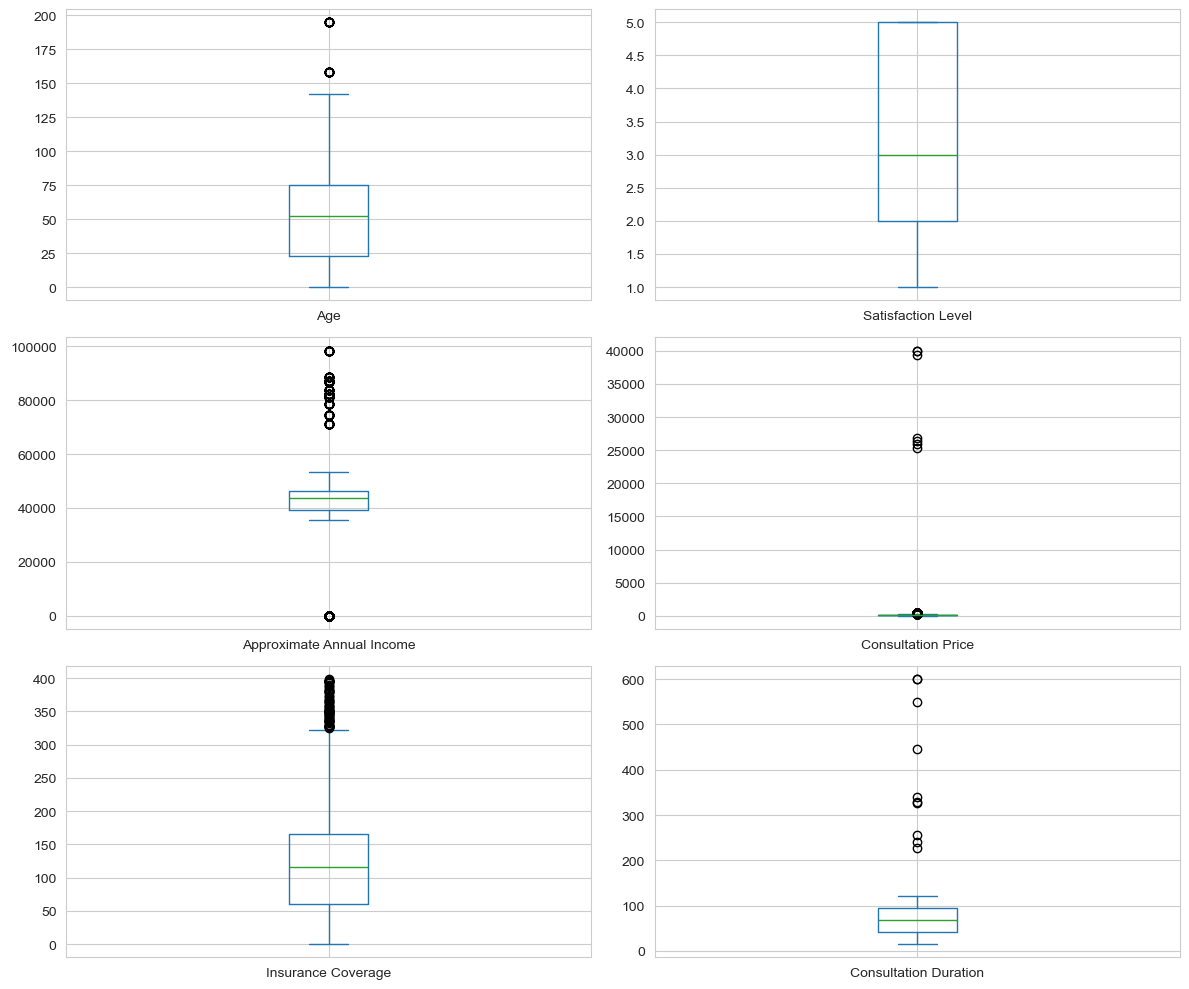

In [122]:
numeric_cols = ['Age','Satisfaction Level','Approximate Annual Income',
                'Consultation Price','Insurance Coverage', 'Consultation Duration']

df[numeric_cols].plot(kind='box', subplots=True, layout=(3,2), figsize=(12,10))
plt.tight_layout()

<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Calculating the Interquartile Range (IQR) for numeric columns and counting the number of outliers beyond <code>1.5 × IQR</code> below Q1 or above Q3:</ul>
</div>

In [123]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
            (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print(outliers)

Age                            36
Satisfaction Level              0
Approximate Annual Income    2390
Consultation Price            240
Insurance Coverage             77
Consultation Duration          10
dtype: int64


<br>

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10007
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Patient ID                 10000 non-null  int64         
 1   Age                        9944 non-null   float64       
 2   Gender                     10000 non-null  object        
 3   City of Residence          10000 non-null  object        
 4   Profession                 10000 non-null  object        
 5   Insurance Provider         8093 non-null   object        
 6   Family History             8010 non-null   object        
 7   Education Level            9971 non-null   object        
 8   Marital Status             10000 non-null  object        
 9   Visit Date                 10000 non-null  datetime64[ns]
 10  Department                 10000 non-null  object        
 11  Consultation Duration      10000 non-null  int64         
 12  Satisfact

<div style="font-size:15px; line-height:1.3;">
Since we have 10000 rows in total, the maximum amount of rows we cand drop is about 5% of the total no. of rows which is 500.
</div>


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Plotting histograms for numeric columns to visualize the distribution of values for each variable:</ul>
</div>


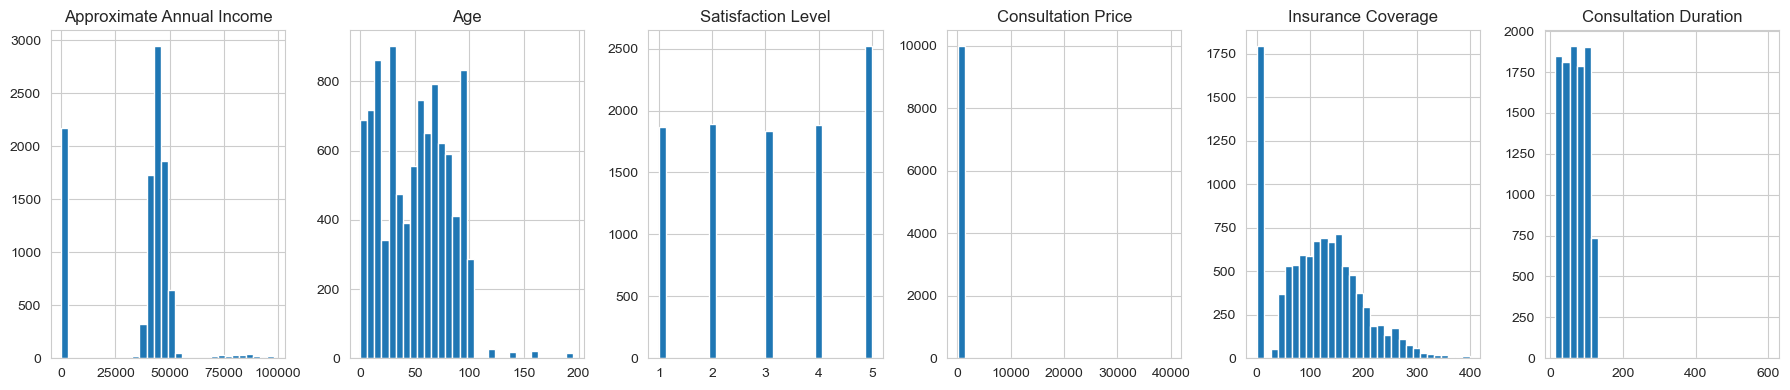

In [126]:
cols = [
    'Approximate Annual Income',
    'Age',
    'Satisfaction Level',
    'Consultation Price',
    'Insurance Coverage',
    'Consultation Duration'
]

plt.figure(figsize=(18, 4))   # largura maior para caberem lado a lado

for i, col in enumerate(cols, 1):
    plt.subplot(1, len(cols), i)  # 1 linha, n colunas
    df[col].hist(bins=30)
    plt.title(col)
    plt.tight_layout()

plt.show()


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>For <code>Age</code>:</ul>
</div>

Upper limit (99th percentile): 100.00 year old.
There are 82 records with age greater than the 99th percentile.
count    9944.000000
mean       50.426991
std        30.932474
min         0.000000
25%        23.000000
50%        52.000000
75%        75.000000
max       195.000000
Name: Age, dtype: float64


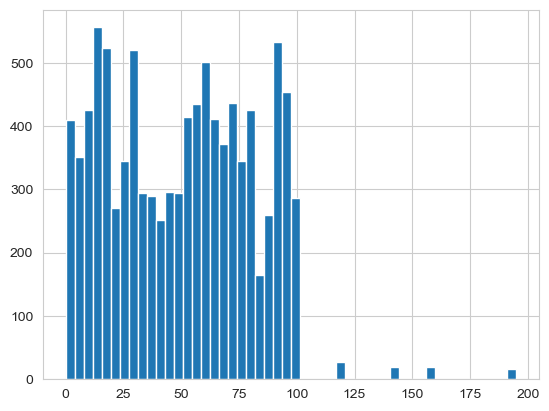

In [127]:
upper_limit = df['Age'].quantile(0.99)

print(f"Upper limit (99th percentile): {upper_limit:.2f} year old.")
print(f"There are {df[df['Age'] > upper_limit].shape[0]} records with age greater than the 99th percentile.")
print(df['Age'].describe())
df['Age'].hist(bins=50) 
plt.show()

<br>

In [128]:
#Since there are only 82 records with age greater than the 99th percentile, we drop them because they are errors
df = df[df['Age'] <= upper_limit]
print(df['Age'].describe())

count    9862.000000
mean       49.612857
std        29.632218
min         0.000000
25%        23.000000
50%        51.000000
75%        74.000000
max       100.000000
Name: Age, dtype: float64


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>For <code>Consultation Price</code>:</ul>
</div>

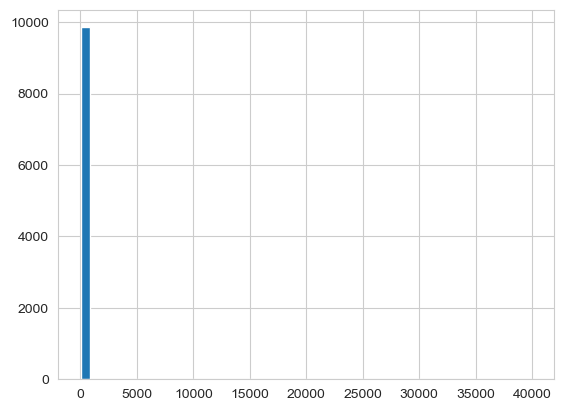

In [129]:
df['Consultation Price'].hist(bins=50) 
plt.show()

<br>

In [130]:
upper_limit = df['Consultation Price'].quantile(0.99)

print(f"Upper limit (99th percentile): £{upper_limit:.2f}")
print(f"There are {df[df['Consultation Price'] > upper_limit].shape[0]} records with age greater than the 99th percentile.")
print(df['Consultation Price'].describe())

Upper limit (99th percentile): £374.24
There are 99 records with age greater than the 99th percentile.
count     9862.000000
mean       184.310977
std        826.825023
min         50.036762
25%        110.941506
50%        159.214954
75%        199.072671
max      39999.222018
Name: Consultation Price, dtype: float64


<br>

In [131]:
df = df[df['Consultation Price'] <= upper_limit]
print(df['Consultation Price'].describe())

count    9763.000000
mean      162.317097
std        67.989414
min        50.036762
25%       110.397617
50%       158.322147
75%       197.847054
max       374.224336
Name: Consultation Price, dtype: float64


<br>

In [132]:
upper_limit = df['Consultation Duration'].quantile(0.99)

print(f"Upper limit (99th percentile): {upper_limit:.2f} minutes")
print(f"There are {df[df['Consultation Duration'] > upper_limit].shape[0]} records with age greater than the 99th percentile.")
print(df['Consultation Duration'].describe())

Upper limit (99th percentile): 119.00 minutes
There are 85 records with age greater than the 99th percentile.
count    9763.000000
mean       67.765236
std        32.483592
min        15.000000
25%        41.000000
50%        68.000000
75%        94.000000
max       600.000000
Name: Consultation Duration, dtype: float64


<br>

In [133]:
df = df[df['Consultation Duration'] <= upper_limit]
print(df['Consultation Duration'].describe())

count    9678.000000
mean       67.026038
std        30.241372
min        15.000000
25%        41.000000
50%        67.000000
75%        93.000000
max       119.000000
Name: Consultation Duration, dtype: float64


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Calculating the Interquartile Range (IQR) for each numeric column and counting the number of outliers that fall below <code>Q1 - 1.5×IQR</code> or <code>above Q3 + 1.5×IQR</code>:</ul>
</div>


In [134]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
            (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print(outliers)

Age                             0
Satisfaction Level              0
Approximate Annual Income    2307
Consultation Price            150
Insurance Coverage             50
Consultation Duration           0
dtype: int64


<br>

### <font> <strong> 1.7. Handling missing values </strong></font> <a class="anchor" id='1_7'></a>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Checking the number of missing values for each column:</ul>
</div>

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9678 entries, 0 to 10006
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Patient ID                 9678 non-null   int64         
 1   Age                        9678 non-null   float64       
 2   Gender                     9678 non-null   object        
 3   City of Residence          9678 non-null   object        
 4   Profession                 9678 non-null   object        
 5   Insurance Provider         7818 non-null   object        
 6   Family History             7754 non-null   object        
 7   Education Level            9649 non-null   object        
 8   Marital Status             9678 non-null   object        
 9   Visit Date                 9678 non-null   datetime64[ns]
 10  Department                 9678 non-null   object        
 11  Consultation Duration      9678 non-null   int64         
 12  Satisfacti

In [136]:
print(df.isnull().sum())

Patient ID                      0
Age                             0
Gender                          0
City of Residence               0
Profession                      0
Insurance Provider           1860
Family History               1924
Education Level                29
Marital Status                  0
Visit Date                      0
Department                      0
Consultation Duration           0
Satisfaction Level              0
Approximate Annual Income      35
Consultation Price              0
Insurance Coverage             49
dtype: int64


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Filling missing values by propagating patient-level data and replacing any remaining gaps with 'Unknown':</ul>
</div>

In [137]:
cols_with_miss_values = ['Insurance Provider', 'Family History', 'Education Level', 
                      'Approximate Annual Income']

for col in cols_with_miss_values:
    df[col] = df.groupby('Patient ID')[col].ffill().bfill()

# 2. Handle remaining missing values after patient-level fill

# Insurance Provider - remaining NaN become 'Unknown'
df['Insurance Provider'] = df['Insurance Provider'].fillna('Unknown')

# Family History - remaining NaN become 'Unknown'
df['Family History'] = df['Family History'].fillna('Unknown')

# Check results
print(df.isnull().sum())

Patient ID                    0
Age                           0
Gender                        0
City of Residence             0
Profession                    0
Insurance Provider            0
Family History                0
Education Level               0
Marital Status                0
Visit Date                    0
Department                    0
Consultation Duration         0
Satisfaction Level            0
Approximate Annual Income     0
Consultation Price            0
Insurance Coverage           49
dtype: int64


<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Filling Insurance Coverage values based on the corresponding Insurance Provider and Department:</ul>
</div>

In [28]:
df['Insurance Coverage'] = df.groupby(['Insurance Provider', 'Department'])['Insurance Coverage'].transform(
    lambda x: x.fillna(x.median())
)
print(df.isnull().sum())

Patient ID                      0
Age                            56
Gender                          0
City of Residence               0
Profession                      0
Insurance Provider           1907
Family History               1990
Education Level                29
Marital Status                  0
Visit Date                      0
Department                      0
Consultation Duration           0
Satisfaction Level              0
Approximate Annual Income      35
Consultation Price              0
Insurance Coverage           1907
dtype: int64


<br>

### <font color='#0EE071'>2. Part B –  Feature Engineering & ABT Construction </font> <a class="anchor" id="2"></a>
  [Back to TOC](#toc)

In [139]:
ABT_city_hospital = df.groupby("Patient ID").agg({
    "Age": "first",
    "Gender": "first",
    "City of Residence": "first",
    "Profession": "first",
    "Education Level": "first",
    "Marital Status": "first",
    "Family History": "first",
    "Approximate Annual Income": "first",
    "Insurance Provider": "first",
    "Insurance Coverage": "mean",
    "Satisfaction Level": "mean",
    "Consultation Duration": "mean",
    "Consultation Price": "mean"
}).reset_index()

ABT_city_hospital = ABT_city_hospital.rename(columns={
    'Insurance Coverage': 'Avg_Insurance_Coverage',
    'Satisfaction Level': 'Avg_Satisfaction_Level',
    'Consultation Duration': 'Avg_Consultation_Duration',
    'Consultation Price': 'Avg_Consultation_Price'
})



ABT_city_hospital.head()

,Patient ID,Age,Gender,City of Residence,Profession,Education Level,Marital Status,Family History,Approximate Annual Income,Insurance Provider,Avg_Insurance_Coverage,Avg_Satisfaction_Level,Avg_Consultation_Duration,Avg_Consultation_Price
0,1001,55.0,Male,Liverpool,Lawyer,Undergraduate,Married,Heart Disease,41338.5,Provider C,104.868129,3.187500,60.500000,149.811613
1,1002,10.0,Female,Liverpool,Student,Elementary school,Single,Cancer,0.0,Provider C,113.526576,3.444444,71.055556,162.180823
2,1003,91.0,Male,Manchester,Retired,Master,Married,Cancer,43130.5,Provider A,136.975834,3.208333,61.916667,171.219793
3,1004,11.0,Male,Glasgow,Student,Middle school/junior high,Single,Cancer,0.0,Provider B,155.289553,3.269231,62.653846,172.543948
4,1005,60.0,Female,Edinburgh,Teacher,Master,Widowed,Hypertension,45904.0,Provider A,0.000000,3.407407,65.111111,149.449363


<br>

In [140]:
def categorize_age(age):
    if age < 18:
        return 'Minor (0-17)'
    elif age < 35:
        return 'Young Adult (18-34)'
    elif age < 50:
        return 'Middle Age (35-49)'
    elif age < 65:
        return 'Mature Adult (50-64)'
    else:
        return 'Senior (65+)'

ABT_city_hospital['Age Group'] = ABT_city_hospital['Age'].apply(categorize_age)

def categorize_income(income):
    if income == 0:
        return 'No Income'
    elif income < 25000:
        return 'Low (0-25k)'
    elif income < 50000:
        return 'Medium (25-50k)'
    elif income < 75000:
        return 'High (50-75k)'
    else:
        return 'Very High (75k+)'

ABT_city_hospital['Income Group'] = ABT_city_hospital['Approximate Annual Income'].apply(categorize_income)

ABT_city_hospital['Total Visits'] = df.groupby('Patient ID').size().values

<br>

In [141]:
# Get the most frequent department for each patient
most_visited_dept = df.groupby('Patient ID')['Department'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
).reset_index()
most_visited_dept.columns = ['Patient ID', 'Most Visited Department']

# Add to ABT
ABT_city_hospital = ABT_city_hospital.merge(most_visited_dept, on='Patient ID', how='left')

<br>

In [142]:
# 1. Calculate Recency (Days since last visit)
# We use the latest date in the entire dataset as the "current" date for calculation
max_date = df['Visit Date'].max()

recency_df = df.groupby('Patient ID')['Visit Date'].max().reset_index()
recency_df['Last Visit (Days)'] = (max_date - recency_df['Visit Date']).dt.days

# 2. Calculate Total Spent (Sum) and Satisfaction Volatility (Std)
behavior_metrics = df.groupby('Patient ID').agg({
    'Consultation Price': 'sum',
    'Satisfaction Level': 'std'
}).reset_index()
behavior_metrics.rename(columns={
    'Consultation Price': 'Total Spent', 
    'Satisfaction Level': 'Satisfaction Volatility'
}, inplace=True)

# Fill NaN variance (for patients with only 1 visit) with 0
behavior_metrics['Satisfaction Volatility'] = behavior_metrics['Satisfaction Volatility'].fillna(0)

# 3. Pivot Departments (Count of visits per department per patient)
dept_pivot = pd.pivot_table(
    df, 
    index='Patient ID', 
    columns='Department', 
    values='Visit Date', 
    aggfunc='count', 
    fill_value=0
).reset_index()

# Rename columns to be cleaner (e.g., "Cardiology" -> "Visits_Cardiology")
dept_pivot.columns = ['Patient ID'] + ['Visits_' + col for col in dept_pivot.columns if col != 'Patient ID']

# --- MERGE EVERYTHING INTO THE MAIN ABT ---
ABT_city_hospital = ABT_city_hospital.merge(recency_df[['Patient ID', 'Last Visit (Days)']], on='Patient ID', how='left')
ABT_city_hospital = ABT_city_hospital.merge(behavior_metrics, on='Patient ID', how='left')
ABT_city_hospital = ABT_city_hospital.merge(dept_pivot, on='Patient ID', how='left')

# Check the final shape
print(ABT_city_hospital.shape)

(496, 34)


<br>

In [143]:
ABT_city_hospital.head()

,Patient ID,Age,Gender,City of Residence,Profession,Education Level,Marital Status,Family History,Approximate Annual Income,Insurance Provider,...,Visits_ENT,Visits_Emergency,Visits_Endocrinology,Visits_Gastroenterology,Visits_General Practice,Visits_Neurology,Visits_Orthopedics,Visits_Psychiatry,Visits_Pulmonology,Visits_Rheumatology
0,1001,55.0,Male,Liverpool,Lawyer,Undergraduate,Married,Heart Disease,41338.5,Provider C,...,3,2,1,1,2,1,0,1,0,2
1,1002,10.0,Female,Liverpool,Student,Elementary school,Single,Cancer,0.0,Provider C,...,1,0,0,1,1,3,1,5,1,1
2,1003,91.0,Male,Manchester,Retired,Master,Married,Cancer,43130.5,Provider A,...,2,1,3,1,1,3,2,5,1,4
3,1004,11.0,Male,Glasgow,Student,Middle school/junior high,Single,Cancer,0.0,Provider B,...,0,3,2,4,5,5,0,2,1,0
4,1005,60.0,Female,Edinburgh,Teacher,Master,Widowed,Hypertension,45904.0,Provider A,...,3,3,0,3,5,1,0,0,2,2


<br>

In [144]:
ABT_city_hospital['Total Spent']

0      2396.985814
1      2919.254806
2      4109.275031
3      4486.142641
4      4035.132809
          ...     
491    3455.637698
492    2837.184125
493    3747.672638
494    3296.909864
495    2621.384306
Name: Total Spent, Length: 496, dtype: float64

<br>

In [145]:
# Calculate total insurance coverage per patient from the original df
total_insurance_coverage = df.groupby('Patient ID')['Insurance Coverage'].sum().reset_index()
total_insurance_coverage.columns = ['Patient ID', 'Total Insurance Coverage']

# Merge this with your ABT_city_hospital dataset
ABT_city_hospital = ABT_city_hospital.merge(total_insurance_coverage, on='Patient ID', how='left')

<br>

In [146]:
ABT_city_hospital['Insurance Coverage Ratio'] = (
    ABT_city_hospital['Total Insurance Coverage'] / 
    ABT_city_hospital['Total Spent']
)

# Display the result
print(ABT_city_hospital[['Patient ID', 'Total Insurance Coverage', 
                          'Total Spent', 'Insurance Coverage Ratio']].head(10))

   Patient ID  Total Insurance Coverage  Total Spent  Insurance Coverage Ratio
0        1001               1677.890070  2396.985814                       0.7
1        1002               2043.478364  2919.254806                       0.7
2        1003               3287.420024  4109.275031                       0.8
3        1004               4037.528377  4486.142641                       0.9
4        1005                  0.000000  4035.132809                       0.0
5        1006               2227.348572  2784.185715                       0.8
6        1007               1911.332617  2730.475167                       0.7
7        1008               2617.796076  3739.708680                       0.7
8        1009               2360.020242  3371.457488                       0.7
9        1010               2075.356937  2964.795624                       0.7


<br>

In [147]:
visit_dates = df.groupby('Patient ID')['Visit Date'].agg(['min', 'max']).reset_index()
visit_dates.columns = ['Patient ID', 'First Visit Date', 'Last Visit Date']

# Merge these with your ABT_city_hospital dataset
ABT_city_hospital = ABT_city_hospital.merge(visit_dates, on='Patient ID', how='left')

<br>

In [148]:
ABT_city_hospital['Average Insurance Coverage per Visit'] = (
    ABT_city_hospital['Total Insurance Coverage'] / 
    ABT_city_hospital['Total Visits']
)

<br>

In [149]:
ABT_city_hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 39 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Patient ID                            496 non-null    int64         
 1   Age                                   496 non-null    float64       
 2   Gender                                496 non-null    object        
 3   City of Residence                     496 non-null    object        
 4   Profession                            496 non-null    object        
 5   Education Level                       496 non-null    object        
 6   Marital Status                        496 non-null    object        
 7   Family History                        496 non-null    object        
 8   Approximate Annual Income             496 non-null    float64       
 9   Insurance Provider                    496 non-null    object        
 10  Av

<br>

In [150]:
ABT_city_hospital.head()

,Patient ID,Age,Gender,City of Residence,Profession,Education Level,Marital Status,Family History,Approximate Annual Income,Insurance Provider,...,Visits_Neurology,Visits_Orthopedics,Visits_Psychiatry,Visits_Pulmonology,Visits_Rheumatology,Total Insurance Coverage,Insurance Coverage Ratio,First Visit Date,Last Visit Date,Average Insurance Coverage per Visit
0,1001,55.0,Male,Liverpool,Lawyer,Undergraduate,Married,Heart Disease,41338.5,Provider C,...,1,0,1,0,2,1677.890070,0.7,2024-01-02,2024-06-27,104.868129
1,1002,10.0,Female,Liverpool,Student,Elementary school,Single,Cancer,0.0,Provider C,...,3,1,5,1,1,2043.478364,0.7,2024-01-06,2024-06-23,113.526576
2,1003,91.0,Male,Manchester,Retired,Master,Married,Cancer,43130.5,Provider A,...,3,2,5,1,4,3287.420024,0.8,2024-01-03,2024-06-29,136.975834
3,1004,11.0,Male,Glasgow,Student,Middle school/junior high,Single,Cancer,0.0,Provider B,...,5,0,2,1,0,4037.528377,0.9,2024-01-01,2024-06-28,155.289553
4,1005,60.0,Female,Edinburgh,Teacher,Master,Widowed,Hypertension,45904.0,Provider A,...,1,0,0,2,2,0.000000,0.0,2024-01-05,2024-06-29,0.000000


<br>

In [151]:
ABT_city_hospital.map(type).nunique()

Patient ID                              1
Age                                     1
Gender                                  1
City of Residence                       1
Profession                              1
Education Level                         1
Marital Status                          1
Family History                          1
Approximate Annual Income               1
Insurance Provider                      1
Avg_Insurance_Coverage                  1
Avg_Satisfaction_Level                  1
Avg_Consultation_Duration               1
Avg_Consultation_Price                  1
Age Group                               1
Income Group                            1
Total Visits                            1
Most Visited Department                 1
Last Visit (Days)                       1
Total Spent                             1
Satisfaction Volatility                 1
Visits_Allergology                      1
Visits_Cardiology                       1
Visits_Dermatology                

<br>

In [152]:
print(f"There are {ABT_city_hospital.duplicated().sum()} duplicate rows in the ABT_city_hospital dataset.")

There are 0 duplicate rows in the ABT_city_hospital dataset.


<br>

In [153]:
if ABT_city_hospital['Patient ID'].nunique() == ABT_city_hospital.shape[0]:
    print("All the rows in the dataset represent different patients, therefore, there are no repeated patients in this dataset.")
else:
    print("There is one or more duplicate patient Id's in the dataset!")

All the rows in the dataset represent different patients, therefore, there are no repeated patients in this dataset.


<br>

In [154]:
ABT_city_hospital.to_csv("Output/ABT_city_hospital.csv")

<br>

### <font color='##0EE071'>3. Part C – Exploratory Visualization & Insights </font> <a class="anchor" id="3"></a>
  [Back to TOC](#toc)

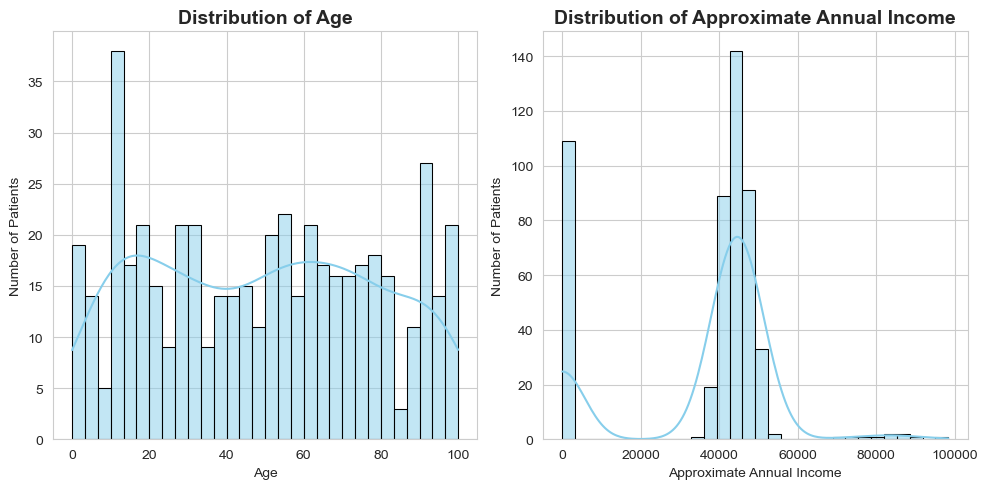

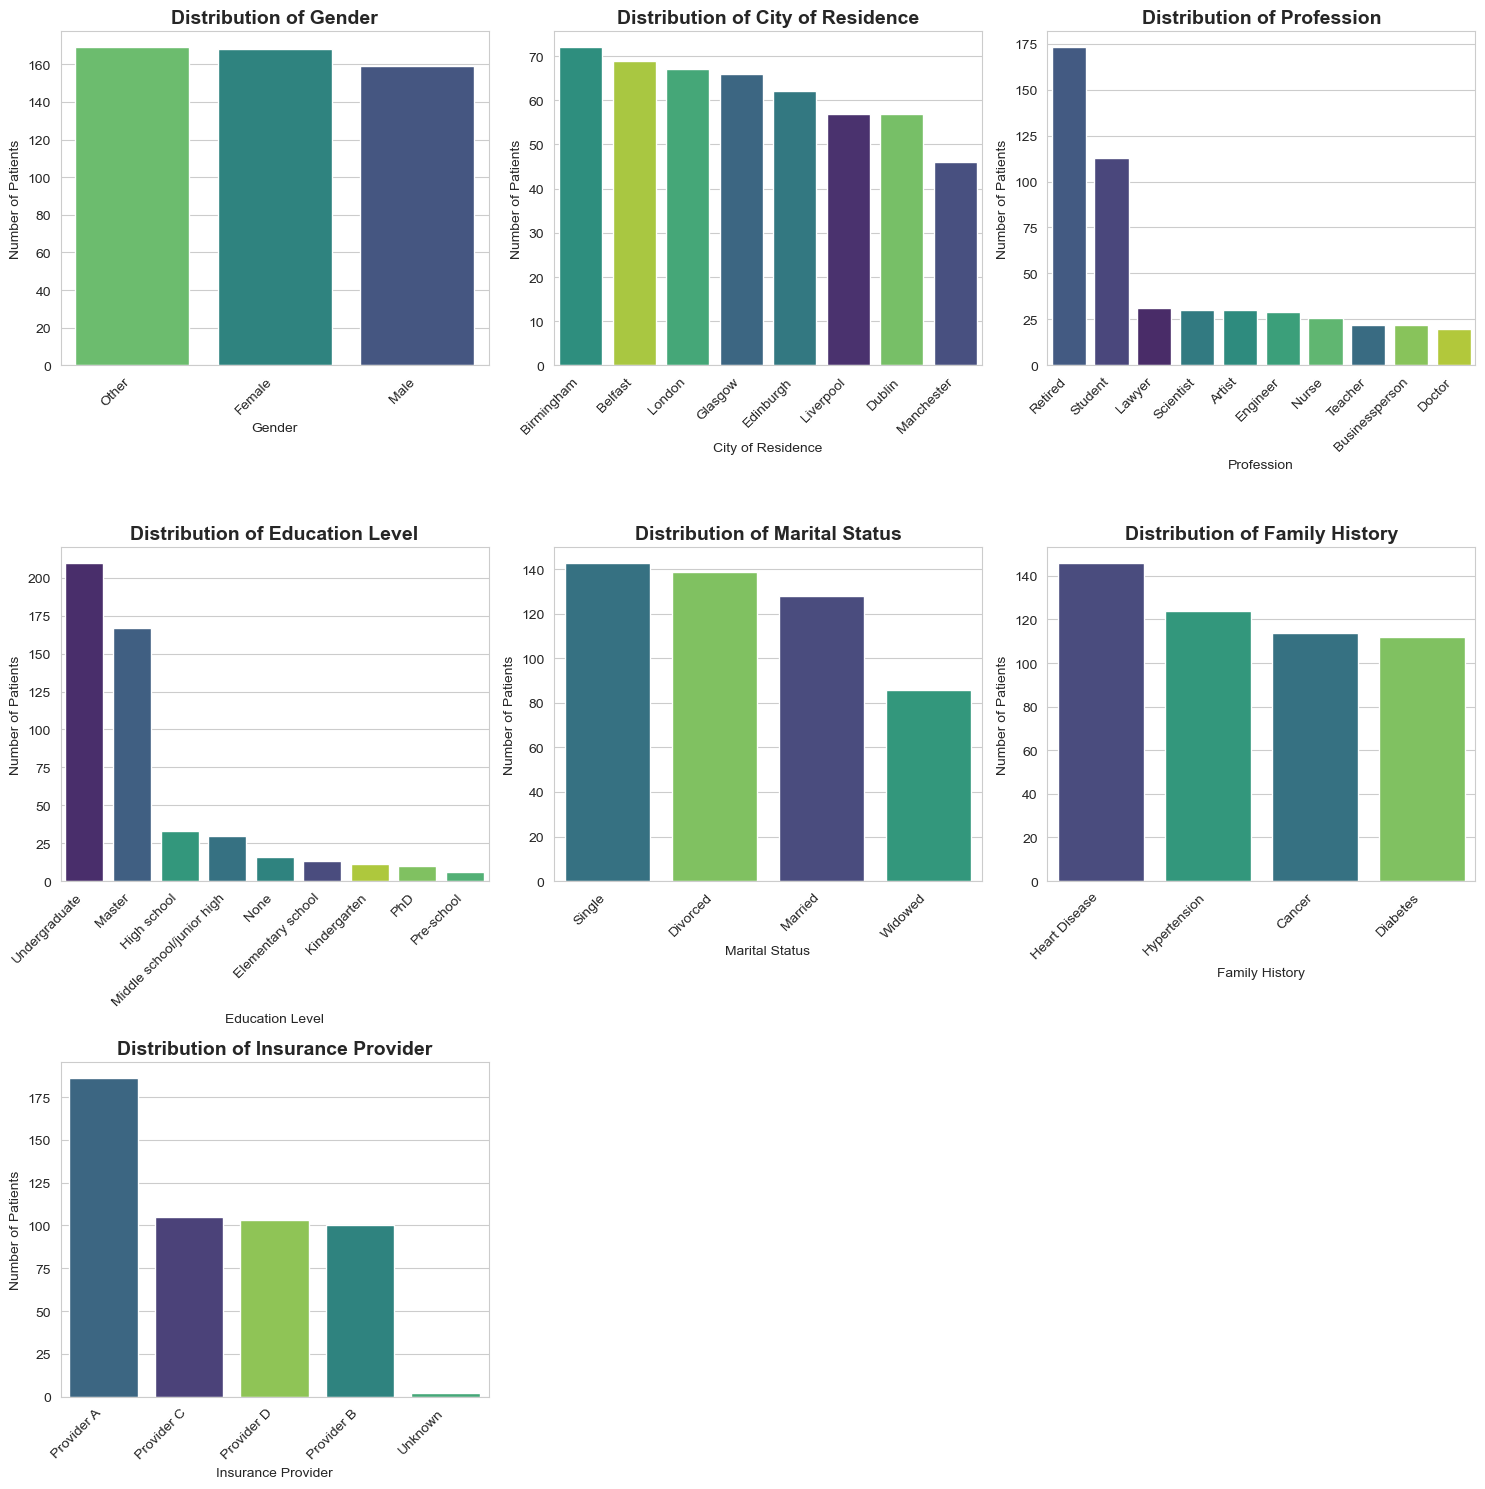

In [155]:
# Set the style for the plots
sns.set_style("whitegrid")

# Define your demographic variables (static patient characteristics only)
numeric_cols = ['Age', 'Approximate Annual Income']
categorical_cols = [
    'Gender', 
    'City of Residence', 
    'Profession', 
    'Education Level', 
    'Marital Status', 
    'Family History',
    'Insurance Provider'
]

# 1. Plot Numerical Distributions (Histograms + KDE)
# CHANGED: Use ABT_city_hospital for patient-level demographics
plt.figure(figsize=(10, 5))  # CHANGED: 10 instead of 15 (only 2 columns now)
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 2, i + 1)  # CHANGED: 1, 2 instead of 1, 3 (only 2 numeric columns)
    sns.histplot(ABT_city_hospital[col], kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Number of Patients')  # CHANGED: More accurate label
plt.tight_layout()
plt.show()

# 2. Plot Categorical Distributions (Bar Charts)
# Use ABT_city_hospital for patient-level demographics
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Count frequencies and sort for better readability
    order = ABT_city_hospital[col].value_counts().index
    
    sns.countplot(data=ABT_city_hospital, x=col, hue=col, order=order, 
                 palette='viridis', legend=False)
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=45, ha='right')
    
plt.tight_layout()
plt.show()

<br>

<br>

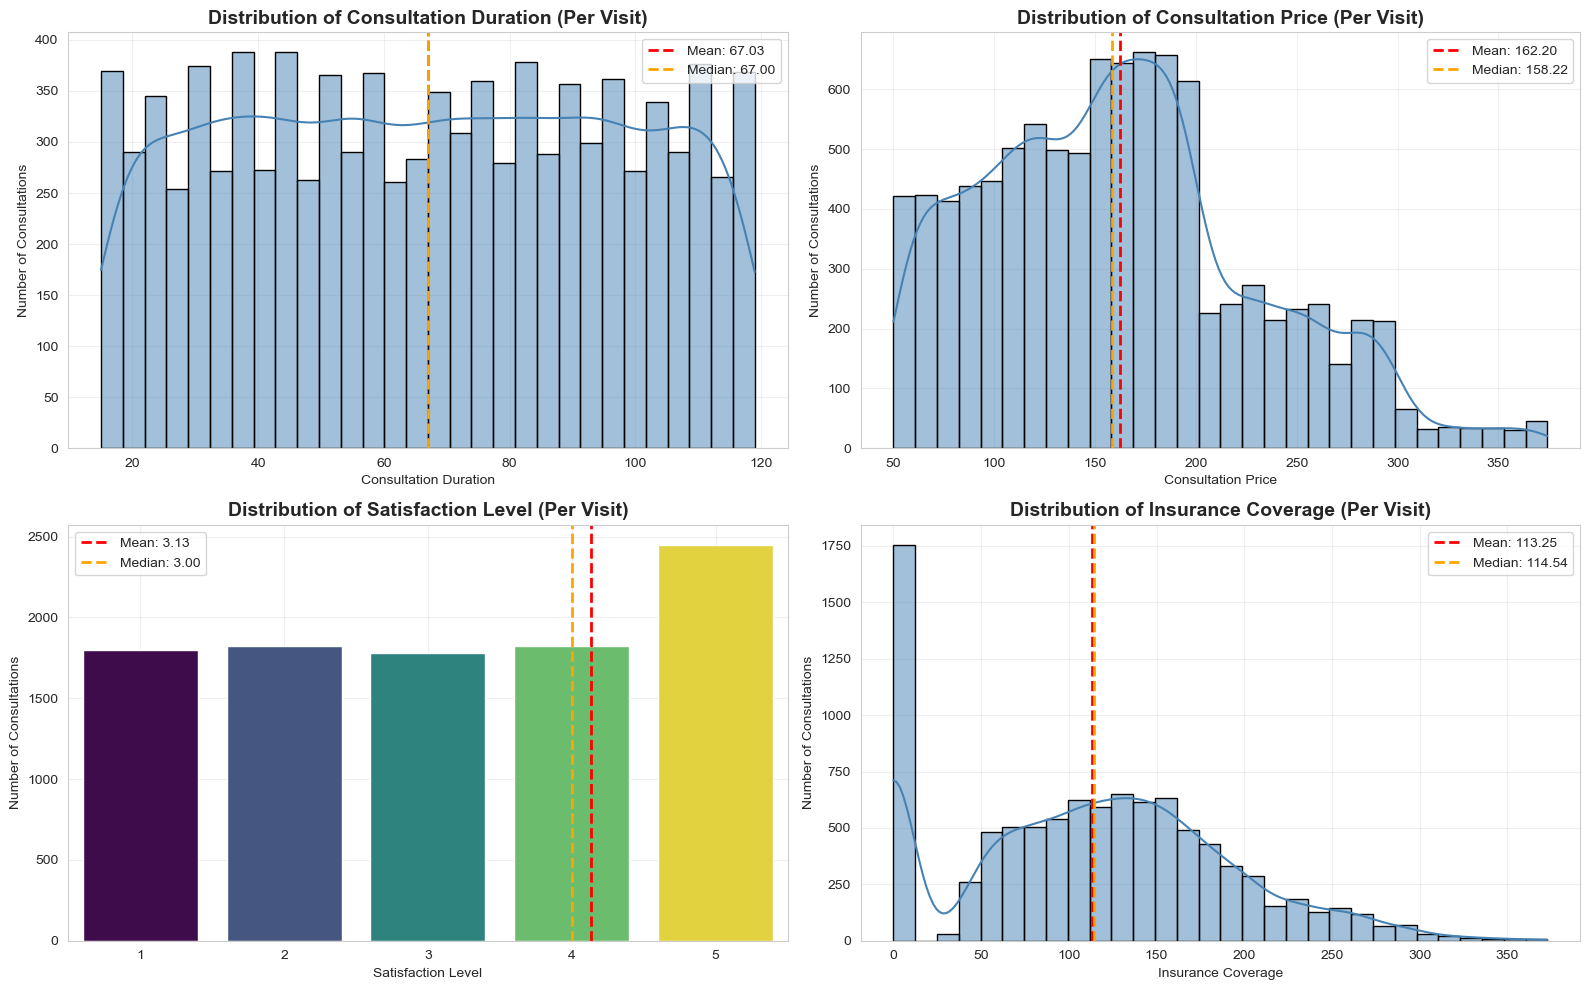

In [156]:
# Set the style for the plots
sns.set_style("whitegrid")

# Define your visit-level variables (dynamic - change across consultations)
visit_variables = [
    'Consultation Duration',
    'Consultation Price', 
    'Satisfaction Level',
    'Insurance Coverage'
]

# --- Plot Visit-Level Variable Distributions (Histograms + KDE) ---
plt.figure(figsize=(16, 10))

for i, col in enumerate(visit_variables):
    plt.subplot(2, 2, i + 1)
    
    # Special handling for Satisfaction Level (discrete variable)
    if col == 'Satisfaction Level':
        # Use countplot for discrete satisfaction levels
        satisfaction_counts = df[col].value_counts().sort_index()
        sns.barplot(x=satisfaction_counts.index, y=satisfaction_counts.values, 
                   hue=satisfaction_counts.index, palette='viridis', legend=False)
        plt.title(f'Distribution of {col} (Per Visit)', fontsize=14, fontweight='bold')
        plt.xlabel(col)
        plt.ylabel('Number of Consultations')
    else:
        # Use histogram with KDE for continuous variables
        sns.histplot(df[col], kde=True, bins=30, color='steelblue', edgecolor='black')
        plt.title(f'Distribution of {col} (Per Visit)', fontsize=14, fontweight='bold')
        plt.xlabel(col)
        plt.ylabel('Number of Consultations')
    
    # Add statistics annotation
    mean_val = df[col].mean()
    median_val = df[col].median()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<br>

<br>

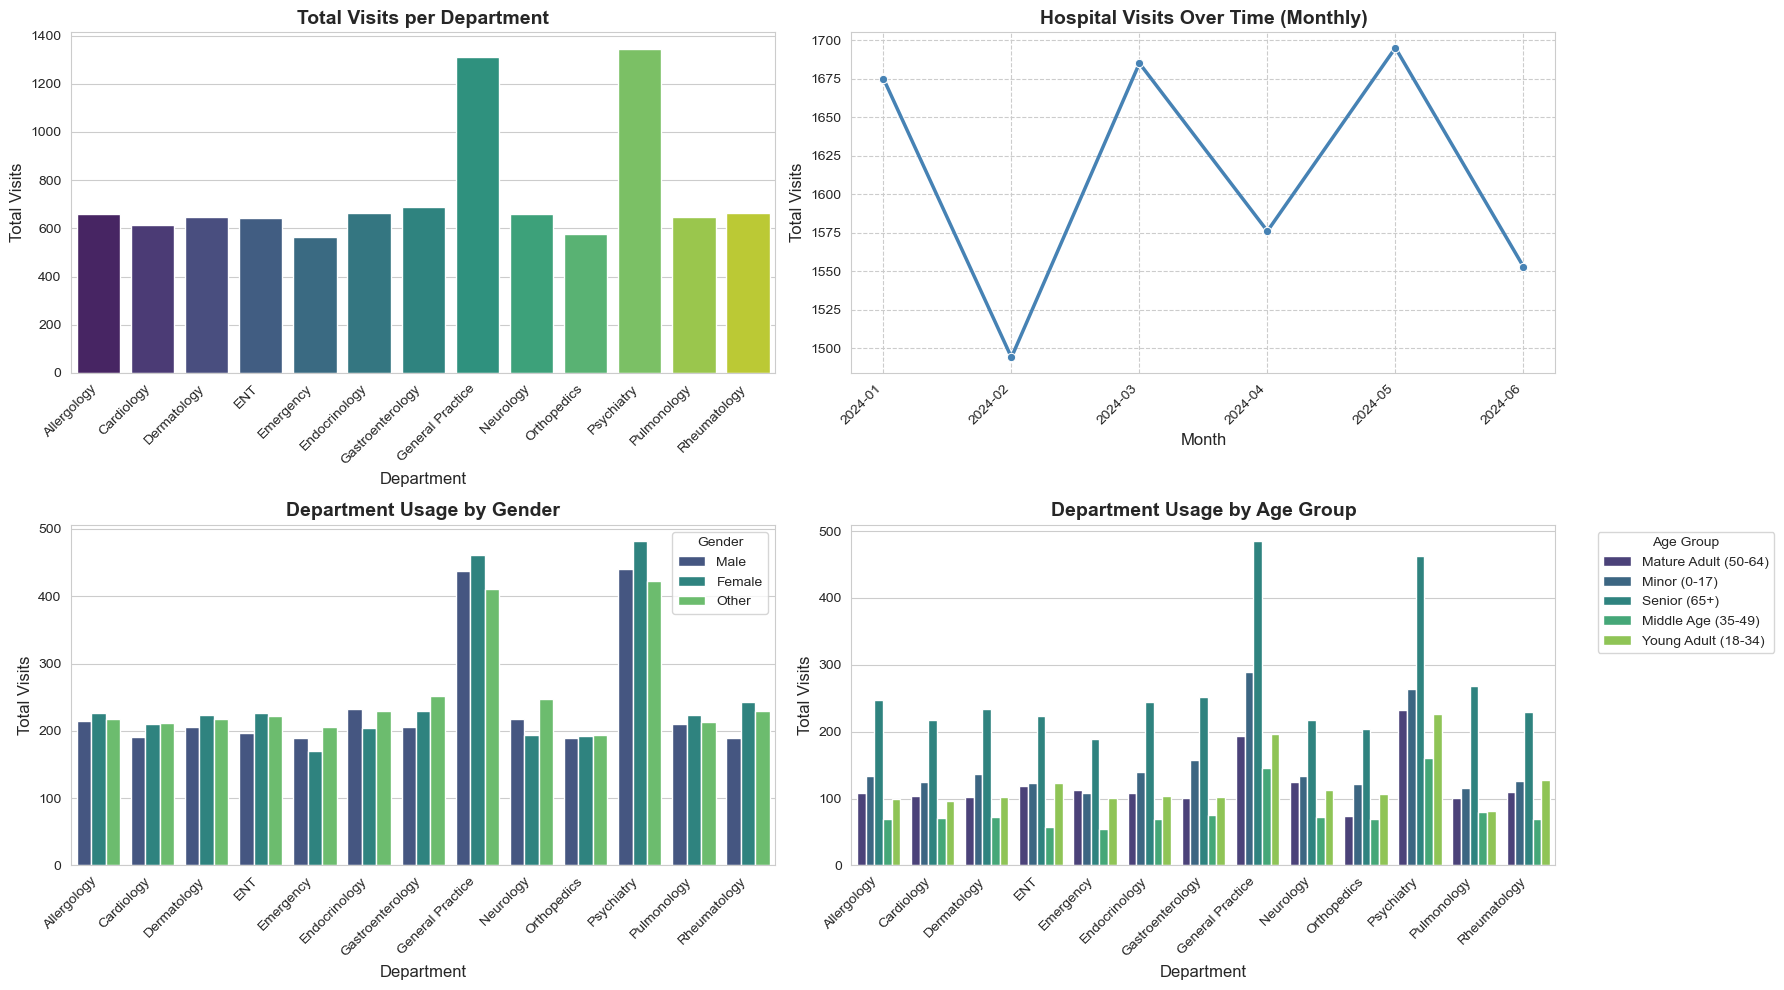

In [157]:
# Set the style
sns.set_style("whitegrid")
plt.figure(figsize=(18, 10))

# 1. Total visits per department (histogram/bar chart)
plt.subplot(2, 2, 1)
# Extract department visit columns
dept_columns = [col for col in ABT_city_hospital.columns if col.startswith('Visits_')]
dept_names = [col.replace('Visits_', '') for col in dept_columns]
# Calculate total visits per department
total_visits = ABT_city_hospital[dept_columns].sum().values
# Create bar plot
sns.barplot(x=dept_names, y=total_visits, hue=dept_names, palette='viridis', legend=False)
plt.title('Total Visits per Department', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Total Visits', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 2. Hospital Visits Over Time (Monthly)
plt.subplot(2, 2, 2)
# Aggregate visits by month - CORRECTED
monthly_counts = df.groupby(df['Visit Date'].dt.to_period('M')).size()
monthly_counts.index = monthly_counts.index.astype(str)  # Convert to string for plotting
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o', color='steelblue', linewidth=2.5)
plt.title('Hospital Visits Over Time (Monthly)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Visits', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--')

# 3. Department usage by gender
plt.subplot(2, 2, 3)
# Prepare data for gender analysis
gender_dept_data = []
for dept_col, dept_name in zip(dept_columns, dept_names):
    for gender in ABT_city_hospital['Gender'].unique():
        total = ABT_city_hospital[ABT_city_hospital['Gender'] == gender][dept_col].sum()
        gender_dept_data.append({'Department': dept_name, 'Gender': gender, 'Visits': total})
gender_dept_df = pd.DataFrame(gender_dept_data)
# Create grouped bar plot
sns.barplot(data=gender_dept_df, x='Department', y='Visits', hue='Gender', palette='viridis')
plt.title('Department Usage by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Total Visits', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()

# 4. Department usage by age group
plt.subplot(2, 2, 4)
# Prepare data for age group analysis
age_dept_data = []
for dept_col, dept_name in zip(dept_columns, dept_names):
    for age_group in ABT_city_hospital['Age Group'].unique():
        total = ABT_city_hospital[ABT_city_hospital['Age Group'] == age_group][dept_col].sum()
        age_dept_data.append({'Department': dept_name, 'Age Group': age_group, 'Visits': total})
age_dept_df = pd.DataFrame(age_dept_data)
# Create grouped bar plot
sns.barplot(data=age_dept_df, x='Department', y='Visits', hue='Age Group', palette='viridis')
plt.title('Department Usage by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Total Visits', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

<br>

<br>

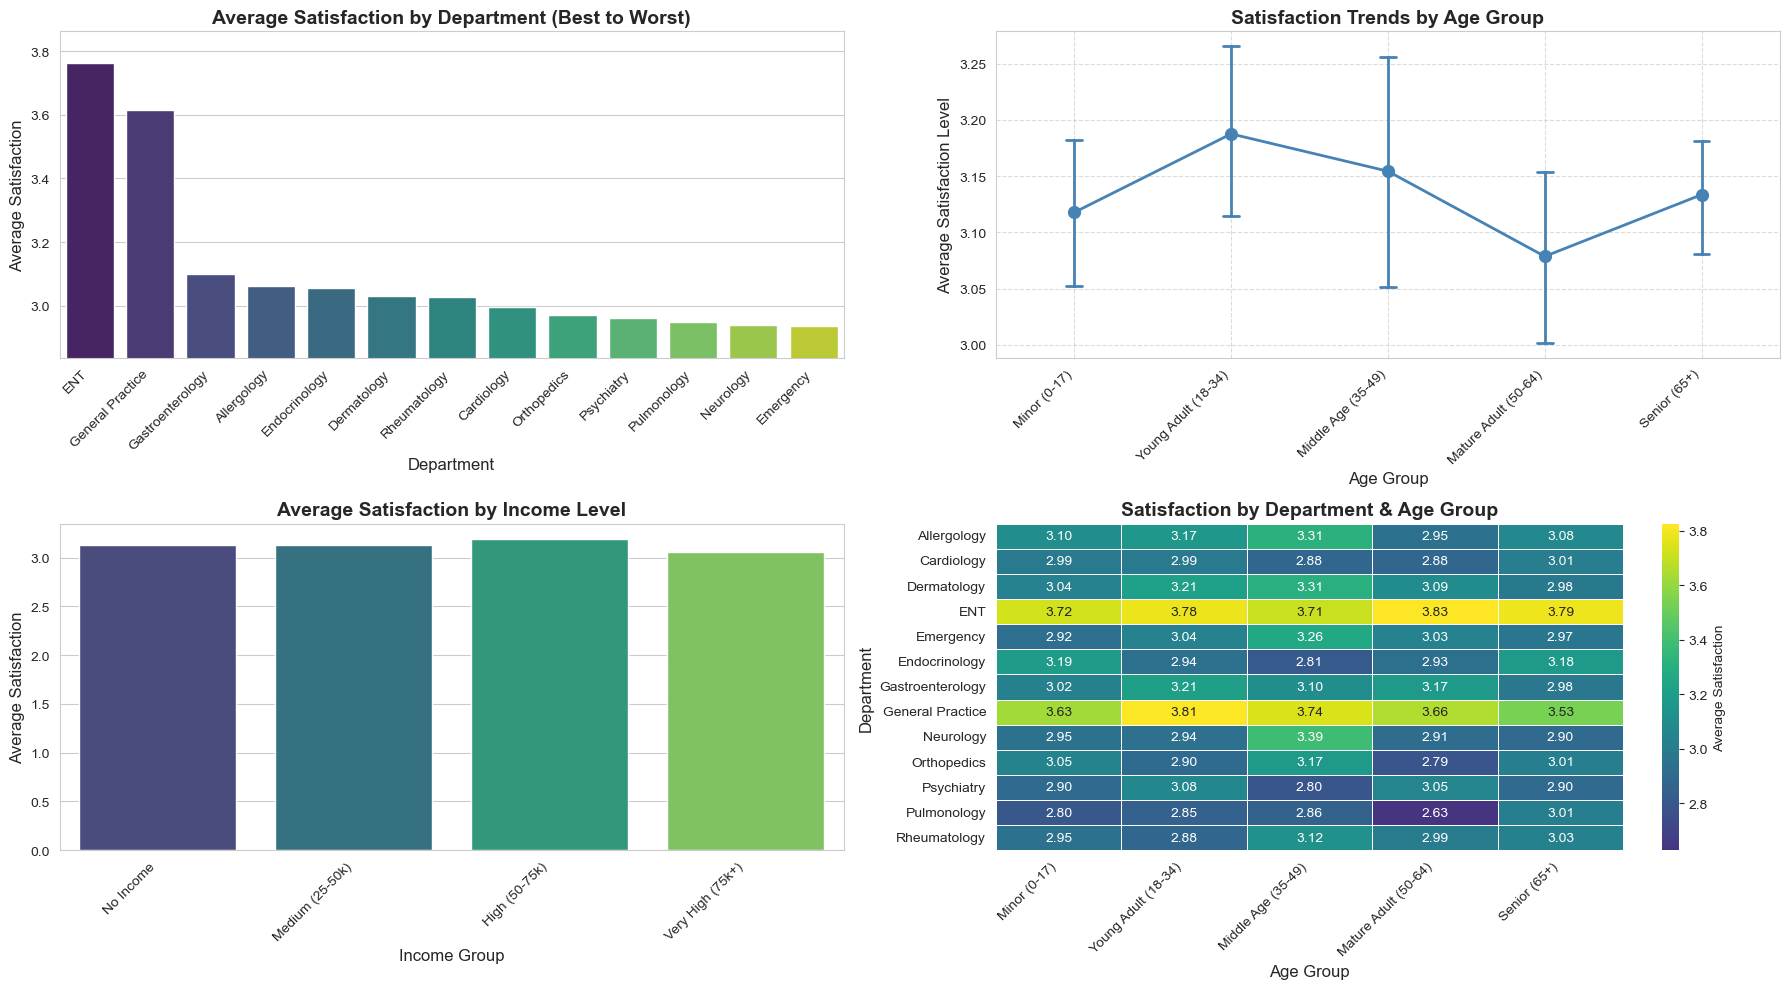

In [158]:
sns.set_style("whitegrid")
plt.figure(figsize=(18, 10))

# Extract department visit columns
dept_columns = [col for col in ABT_city_hospital.columns if col.startswith('Visits_')]
dept_names = [col.replace('Visits_', '') for col in dept_columns]

# 1. Average satisfaction by department (best to worst) - CORRECTED
plt.subplot(2, 2, 1)

# Calculate TRUE average satisfaction per department from original df
dept_satisfaction = df.groupby('Department')['Satisfaction Level'].mean().reset_index()
dept_satisfaction.columns = ['Department', 'Avg Satisfaction']
dept_satisfaction = dept_satisfaction.sort_values('Avg Satisfaction', ascending=False)

sns.barplot(data=dept_satisfaction, x='Department', y='Avg Satisfaction', hue='Department', palette='viridis', legend=False)
plt.title('Average Satisfaction by Department (Best to Worst)', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Satisfaction', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(dept_satisfaction['Avg Satisfaction'].min() - 0.1, dept_satisfaction['Avg Satisfaction'].max() + 0.1)

# 2. Satisfaction trends by age group (pointplot)
plt.subplot(2, 2, 2)

# Define age group order manually
age_order = ['Minor (0-17)', 'Young Adult (18-34)', 'Middle Age (35-49)', 'Mature Adult (50-64)', 'Senior (65+)']

sns.pointplot(data=ABT_city_hospital, x='Age Group', y='Avg_Satisfaction_Level',
              order=age_order, errorbar='ci', capsize=0.1, color='steelblue', linewidth=2, markersize=8)
plt.title('Satisfaction Trends by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Satisfaction Level', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Average satisfaction by income level (histogram)
plt.subplot(2, 2, 3)

# Calculate average satisfaction by income group
# Define income group order manually
income_order = ['No Income', 'Medium (25-50k)', 'High (50-75k)', 'Very High (75k+)']
income_satisfaction = ABT_city_hospital.groupby('Income Group')['Avg_Satisfaction_Level'].mean()
income_satisfaction = income_satisfaction.reindex(income_order)

sns.barplot(x=income_satisfaction.index, y=income_satisfaction.values, 
            hue=income_satisfaction.index, palette='viridis', legend=False)
plt.title('Average Satisfaction by Income Level', fontsize=14, fontweight='bold')
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Average Satisfaction', fontsize=12)
plt.xticks(rotation=45, ha='right')

# 4. Heatmap: Satisfaction by Department & Age Group - CORRECTED
plt.subplot(2, 2, 4)

# Create pivot table from original df for accurate department-age satisfaction
heatmap_data = df.groupby(['Department', 'Age'])['Satisfaction Level'].mean().reset_index()
heatmap_data.columns = ['Department', 'Age', 'Satisfaction']

# Create age groups in the original df temporarily for this visualization
age_bins = [0, 18, 35, 50, 65, 100]
age_labels = ['Minor (0-17)', 'Young Adult (18-34)', 'Middle Age (35-49)', 'Mature Adult (50-64)', 'Senior (65+)']
heatmap_data['Age Group'] = pd.cut(heatmap_data['Age'], bins=age_bins, labels=age_labels, right=False)

heatmap_df = heatmap_data.groupby(['Department', 'Age Group'])['Satisfaction'].mean().reset_index()

# Order age groups manually
age_order = ['Minor (0-17)', 'Young Adult (18-34)', 'Middle Age (35-49)', 'Mature Adult (50-64)', 'Senior (65+)']
heatmap_pivot = heatmap_df.pivot(index='Department', columns='Age Group', values='Satisfaction')
heatmap_pivot = heatmap_pivot[age_order]

sns.heatmap(heatmap_pivot, annot=True, fmt='.2f', cmap='viridis', center=heatmap_pivot.mean().mean(),
            cbar_kws={'label': 'Average Satisfaction'}, linewidths=0.5)
plt.title('Satisfaction by Department & Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

<br>

<br>

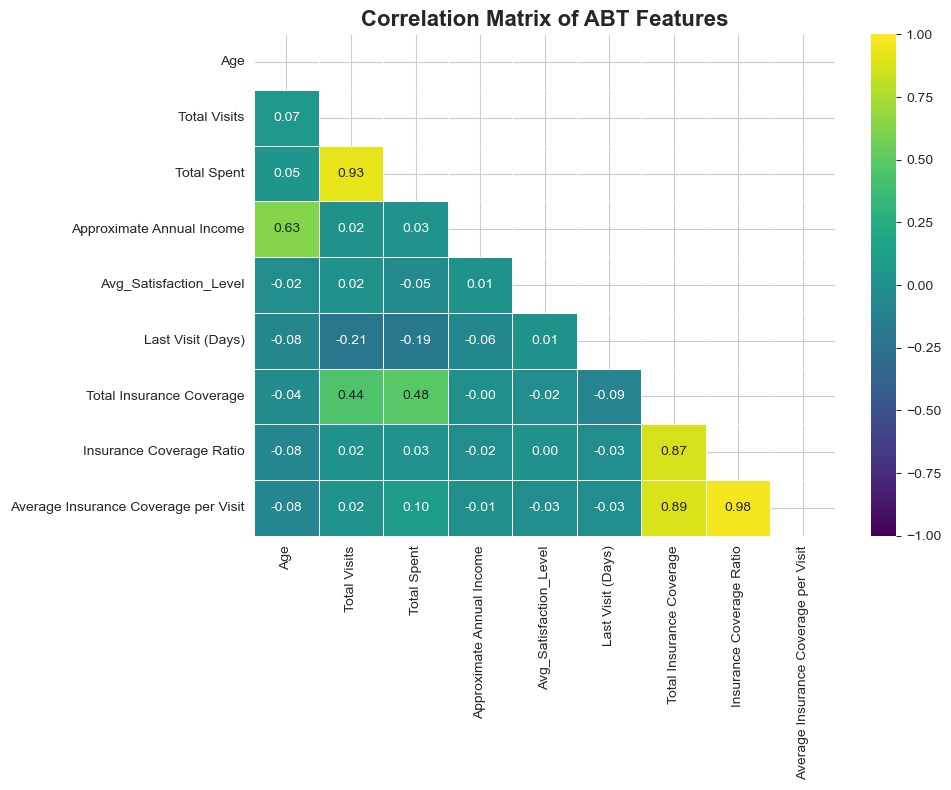

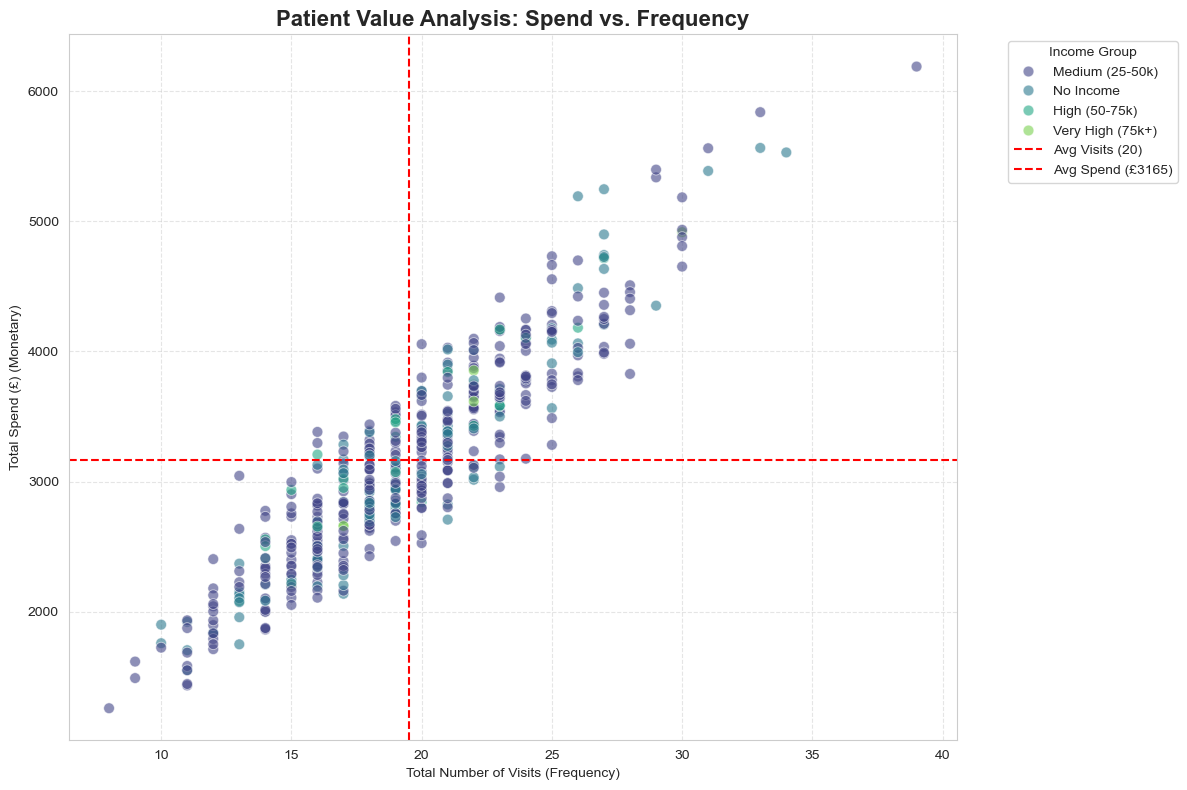

In [159]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))

# Select only numerical columns from your ABT
# Ensure we are using the ABT dataframe here, not the raw visit dataframe
numeric_abt = ABT_city_hospital[['Age', 'Total Visits', 'Total Spent', 'Approximate Annual Income',
                                 'Avg_Satisfaction_Level',  # CORRECTED
                                 'Last Visit (Days)', 
                                 'Total Insurance Coverage', 
                                 'Insurance Coverage Ratio', 
                                 'Average Insurance Coverage per Visit']]

# Calculate correlation
corr = numeric_abt.corr()

# Create mask to hide the upper triangle (since it's a mirror image)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='viridis', 
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of ABT Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Patient Value Segmentation (Spend vs. Visits)
plt.figure(figsize=(12, 8))

# Scatter plot of Spend vs Visits
sns.scatterplot(data=ABT_city_hospital, x='Total Visits', y='Total Spent', 
                hue='Income Group', palette='viridis', alpha=0.6, s=60)
plt.title('Patient Value Analysis: Spend vs. Frequency', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Visits (Frequency)')
plt.ylabel('Total Spend (£) (Monetary)')
plt.grid(True, linestyle='--', alpha=0.5)

# Add reference lines to suggest segments (Optional - adjust values based on your data)
avg_visits = ABT_city_hospital['Total Visits'].mean()
avg_spend = ABT_city_hospital['Total Spent'].mean()
plt.axvline(avg_visits, color='red', linestyle='--', label=f'Avg Visits ({avg_visits:.0f})')
plt.axhline(avg_spend, color='red', linestyle='--', label=f'Avg Spend (£{avg_spend:.0f})')

plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<br>

<br>

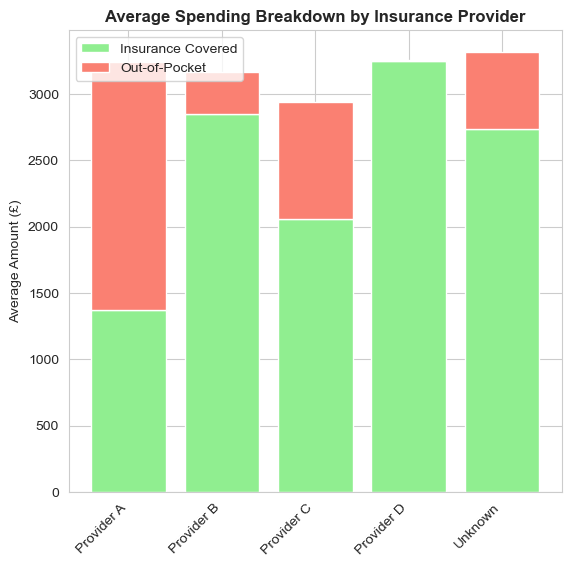

In [160]:
# Calculate out-of-pocket spending
ABT_city_hospital['Out_of_Pocket'] = ABT_city_hospital['Total Spent'] - ABT_city_hospital['Total Insurance Coverage']

plt.figure(figsize=(14, 6))

# Subplot 1: Insurance vs Out-of-Pocket stacked bar by insurance provider
plt.subplot(1, 2, 1)
insurance_spending = ABT_city_hospital.groupby('Insurance Provider').agg({
    'Total Insurance Coverage': 'mean',
    'Out_of_Pocket': 'mean'
}).reset_index()

x = range(len(insurance_spending))
plt.bar(x, insurance_spending['Total Insurance Coverage'], label='Insurance Covered', color='lightgreen')
plt.bar(x, insurance_spending['Out_of_Pocket'], bottom=insurance_spending['Total Insurance Coverage'], 
        label='Out-of-Pocket', color='salmon')
plt.xticks(x, insurance_spending['Insurance Provider'], rotation=45, ha='right')
plt.ylabel('Average Amount (£)')
plt.title('Average Spending Breakdown by Insurance Provider', fontweight='bold')
plt.legend()

<br>

<br>

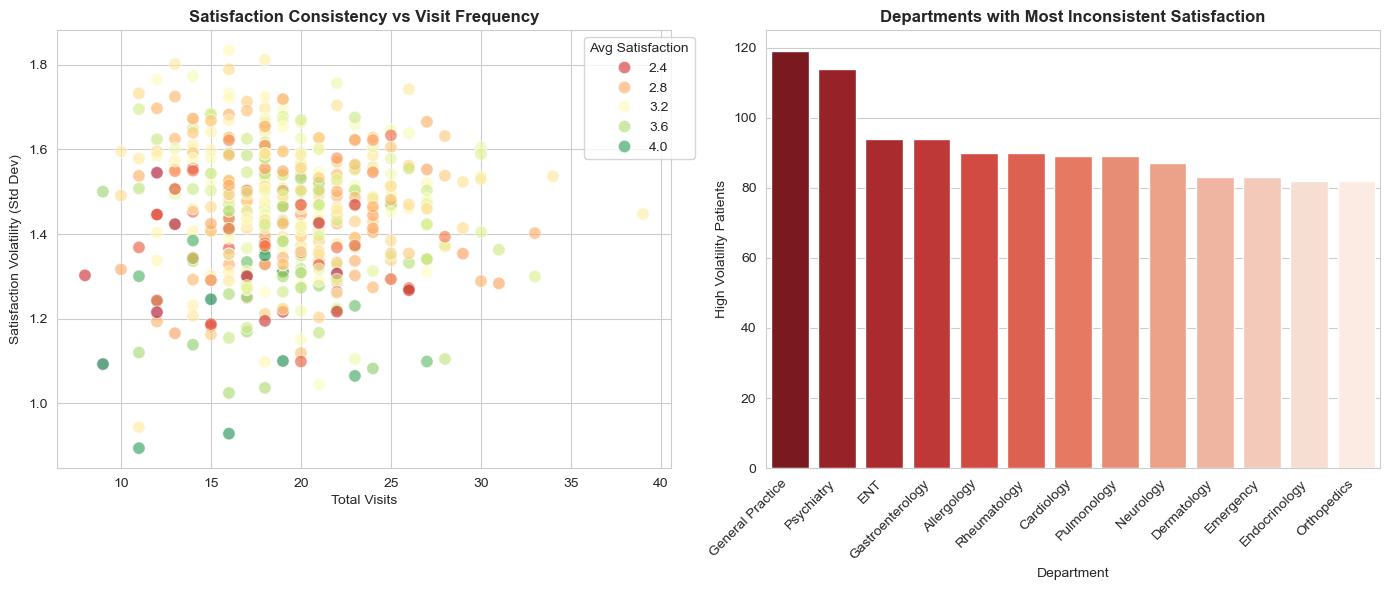

In [161]:
plt.figure(figsize=(14, 6))

# Subplot 1: Satisfaction volatility by total visits
plt.subplot(1, 2, 1)
sns.scatterplot(data=ABT_city_hospital, x='Total Visits', y='Satisfaction Volatility', 
                hue='Avg_Satisfaction_Level', palette='RdYlGn', alpha=0.6, s=80)
plt.title('Satisfaction Consistency vs Visit Frequency', fontweight='bold')
plt.xlabel('Total Visits')
plt.ylabel('Satisfaction Volatility (Std Dev)')
plt.legend(title='Avg Satisfaction', bbox_to_anchor=(1.05, 1))

# Subplot 2: High volatility patients by department
plt.subplot(1, 2, 2)
high_volatility = ABT_city_hospital[ABT_city_hospital['Satisfaction Volatility'] > 
                                     ABT_city_hospital['Satisfaction Volatility'].quantile(0.75)]
dept_volatility = []
for dept_col, dept_name in zip(dept_columns, dept_names):
    count = (high_volatility[dept_col] > 0).sum()
    dept_volatility.append({'Department': dept_name, 'High Volatility Patients': count})

dept_vol_df = pd.DataFrame(dept_volatility).sort_values('High Volatility Patients', ascending=False)
sns.barplot(data=dept_vol_df, x='Department', y='High Volatility Patients', palette='Reds_r')
plt.title('Departments with Most Inconsistent Satisfaction', fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<br>

<br>

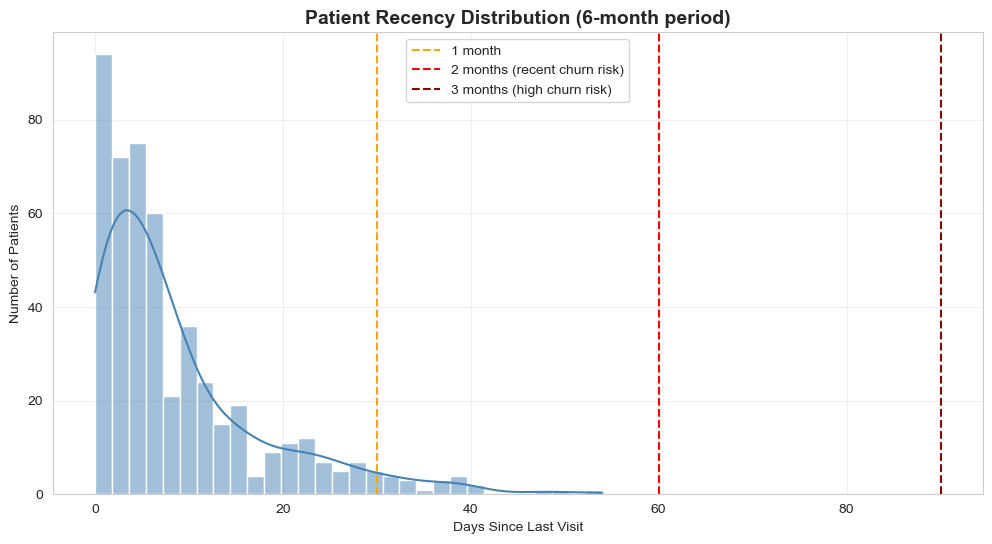

In [162]:
# Days since last visit distribution - adjusted for 6-month context
plt.figure(figsize=(12, 6))
sns.histplot(data=ABT_city_hospital, x='Last Visit (Days)', bins=30, kde=True, color='steelblue')
plt.axvline(x=30, color='orange', linestyle='--', label='1 month')
plt.axvline(x=60, color='red', linestyle='--', label='2 months (recent churn risk)')
plt.axvline(x=90, color='darkred', linestyle='--', label='3 months (high churn risk)')
plt.title('Patient Recency Distribution (6-month period)', fontsize=14, fontweight='bold')
plt.xlabel('Days Since Last Visit')
plt.ylabel('Number of Patients')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()